In [ ]:
# Notebook 03: Model Training & Evaluation

**NeuroLens — Psychiatric Multi-Classifier**

This notebook trains and evaluates three classifiers on preprocessed postmortem brain gene expression data to distinguish schizophrenia (SCZ), bipolar disorder (BD), major depressive disorder (MDD), and healthy controls (CTL).

**Input:** `ml_ready_max_samples.csv` (Version B: 607 samples × 10,678 probes)
- 9 datasets, 2 platforms (GPL570 + GPL96)
- ComBat batch-corrected, outlier-removed, variance-filtered
- StratifiedGroupKFold CV (prevents data leakage from GSE53987 multi-region patients)

**Models:**
1. Logistic Regression (interpretable baseline)
3. XGBoost (primary model, paired with SHAP)

**Evaluation:** , F1 (macro) ( we have unbalance data)

In [1]:
# --- Step 1: Setup ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb
import shap

# Display settings (visual only, no effect on results)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("Libraries loaded.")

/Users/ali/Desktop/ds-bootcamp/psychiatric-multi-classifier-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.


In [2]:
# --- Step 2: Load Data ---

df = pd.read_csv('../data/processed/ml_ready_max_samples.csv', index_col='sample_id')

print(f"Shape: {df.shape}")

print(df['diagnosis'].value_counts())

Shape: (607, 10686)
diagnosis
CTL    227
SCZ    171
BD     134
MDD     75
Name: count, dtype: int64


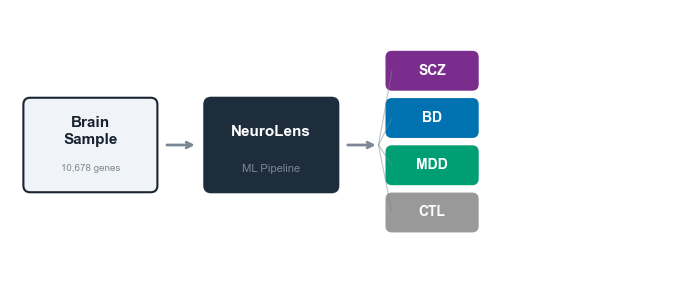

In [151]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

# Brain sample box
ax.add_patch(mpatches.FancyBboxPatch((0.3, 1.4), 1.8, 1.2, boxstyle="round,pad=0.1",
             facecolor='#F0F4F8', edgecolor='#1A2332', linewidth=1.5))
ax.text(1.2, 2.2, 'Brain\nSample', fontsize=11, ha='center', va='center', fontweight='bold', color='#1A2332')
ax.text(1.2, 1.65, '10,678 genes', fontsize=7, ha='center', va='center', color='#7B8794')

# Arrow 1
ax.annotate('', xy=(2.8, 2.0), xytext=(2.3, 2.0),
            arrowprops=dict(arrowstyle='->', color='#7B8794', lw=2))

# ML model box
ax.add_patch(mpatches.FancyBboxPatch((3.0, 1.4), 1.8, 1.2, boxstyle="round,pad=0.1",
             facecolor='#1E2D3C', edgecolor='#1E2D3C', linewidth=1.5))
ax.text(3.9, 2.2, 'NeuroLens', fontsize=11, ha='center', va='center', fontweight='bold', color='white')
ax.text(3.9, 1.65, 'ML Pipeline', fontsize=8, ha='center', va='center', color='#7B8794')

# Arrow 2
ax.annotate('', xy=(5.5, 2.0), xytext=(5.0, 2.0),
            arrowprops=dict(arrowstyle='->', color='#7B8794', lw=2))

# 4 output boxes
disorders = [
    {'name': 'SCZ', 'color': '#7B2D8E', 'y': 3.1},
    {'name': 'BD', 'color': '#0072B2', 'y': 2.4},
    {'name': 'MDD', 'color': '#009E73', 'y': 1.7},
    {'name': 'CTL', 'color': '#999999', 'y': 1.0}
]

for d in disorders:
    ax.add_patch(mpatches.FancyBboxPatch((5.7, d['y'] - 0.2), 1.2, 0.4, boxstyle="round,pad=0.08",
                 facecolor=d['color'], edgecolor=d['color'], linewidth=1.5))
    ax.text(6.3, d['y'], d['name'], fontsize=10, ha='center', va='center', fontweight='bold', color='white')

for d in disorders:
    ax.plot([5.5, 5.7], [2.0, d['y']], color='#7B8794', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('../figures/03_project_goal_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

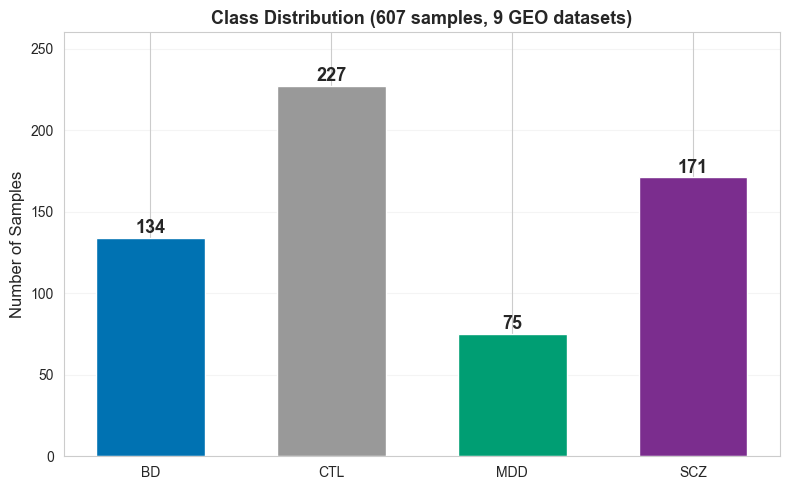

In [134]:
# --- Class Distribution ---
classes = ['BD', 'CTL', 'MDD', 'SCZ']
counts = [134, 227, 75, 171]
colors = ['#0072B2', '#999999', '#009E73', '#7B2D8E']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(classes, counts, color=colors, edgecolor='white', width=0.6)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(count), ha='center', fontweight='bold', fontsize=13)

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution (607 samples, 9 GEO datasets)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 260)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('../figures/03_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

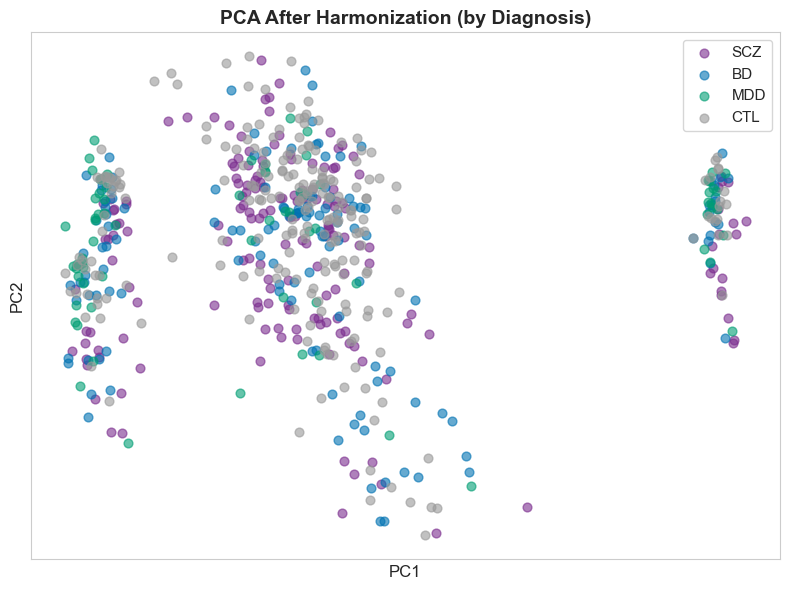

In [143]:
colors = {'SCZ': '#7B2D8E', 'BD': '#0072B2', 'MDD': '#009E73', 'CTL': '#999999'}

pca_after = PCA(n_components=2)
pc_after = pca_after.fit_transform(df[probe_cols].values)

fig, ax = plt.subplots(figsize=(8, 6))

for dx in ['SCZ', 'BD', 'MDD', 'CTL']:
    mask = df['diagnosis'] == dx
    ax.scatter(pc_after[mask, 0], pc_after[mask, 1], 
              label=dx, color=colors[dx], alpha=0.6, s=40)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA After Harmonization (by Diagnosis)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../figures/03_pca_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# --- Step 3: Separate Features, Labels, and Groups ---

# Columns that are NOT gene expression data
meta_cols = ['diagnosis', 'brain_region', 'dataset', 'age', 'sex', 'ph', 'pmi', 'patient_group']

# Everything else is a probe (gene expression feature)
probe_cols = [c for c in df.columns if c not in meta_cols]

X = df[probe_cols]
y = df['diagnosis']
groups = df['patient_group']

print(f"Features: {X.shape[0]} samples, {X.shape[1]} probes")
print(f"Groups: {groups.nunique()} unique patients")

Features: 607 samples, 10678 probes
Groups: 471 unique patients


In [4]:
# --- Step 4: Encode Labels and Set Up Cross-Validation ---

# Convert text labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Show mapping
for i, name in enumerate(le.classes_):
    print(f"  {name} = {i}")

# 5-fold cross-validation (keeps same patient out of both train and test)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nCross-validation: 5-fold StratifiedGroupKFold")

  BD = 0
  CTL = 1
  MDD = 2
  SCZ = 3

Cross-validation: 5-fold StratifiedGroupKFold


In [ ]:
### How the split works (explain)

607 samples, 471 patient groups, split into 5 folds. Each fold: ~80% train, ~20% test.

**Rules:**
- All samples from the same patient stay in the same fold (no leakage)
- Each fold keeps the same class proportions as the full dataset
- Every sample gets tested exactly once across all 5 folds

In [98]:
# --- LR with high C on all 10,678 probes (no PCA) ---

for c_val in [1.0, 5.0, 10.0, 50.0, 100.0]:
    pipe = Pipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(
                class_weight='balanced',
                C=c_val,
                max_iter=5000
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probe_cols],
        y = df['diagnosis'],
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"LR C={c_val:.1f} → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

LR C=1.0 → Train: 1.000, Test: 0.506
LR C=5.0 → Train: 1.000, Test: 0.509
LR C=10.0 → Train: 1.000, Test: 0.479
LR C=50.0 → Train: 1.000, Test: 0.457
LR C=100.0 → Train: 1.000, Test: 0.426


In [6]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate, GridSearchCV

In [7]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Basline Model

In [104]:
from sklearn.metrics import make_scorer, f1_score

f1_scorer = make_scorer(f1_score, average='macro', zero_division=0)

cross_val = cross_validate(
    estimator = DummyClassifier(strategy='most_frequent'),
    X = df[probe_cols],
    y = y_encoded,
    groups = groups,
    scoring = f1_scorer,
    cv = cv,
    return_train_score = True
)

cross_val

{'fit_time': array([0.00349903, 0.00313592, 0.00306606, 0.00289321, 0.00285268]),
 'score_time': array([0.00078273, 0.00068021, 0.00058103, 0.00052094, 0.0004921 ]),
 'test_score': array([0.13690476, 0.13473054, 0.13554217, 0.13554217, 0.13772455]),
 'train_score': array([0.13588589, 0.13643178, 0.13622754, 0.13622754, 0.13568216])}

In [105]:
print(f"Dummy - Train: {np.mean(cross_val['train_score']):.3f}, Test: {np.mean(cross_val['test_score']):.3f}")

Dummy - Train: 0.136, Test: 0.136


In [84]:
n=df.diagnosis.value_counts(normalize= True)['CTL']

In [85]:
k=df.diagnosis.nunique()

In [86]:
f1_macro_dummay=2*n/(k*(n+1))

In [87]:
f1_macro_dummay

0.13609112709832133

In [77]:
# logistic Regression model

pipeline_lr = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('log_reg', LogisticRegression(class_weight='balanced'))
    ]
)

cross_val_lr = cross_validate(
    estimator = pipeline_lr,
    X = df[probe_cols],
    y = df['diagnosis'],
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

cross_val_lr

{'fit_time': array([0.70981288, 0.77012587, 0.70692611, 0.70484877, 0.69184899]),
 'score_time': array([0.0305109 , 0.02878523, 0.02644587, 0.02593422, 0.02667904]),
 'test_score': array([0.52547116, 0.51237727, 0.46911887, 0.4572135 , 0.56771454]),
 'train_score': array([1., 1., 1., 1., 1.])}

In [9]:
# --- LR Baseline with GridSearchCV (reduce overfitting) ---

# Pipeline: scale data first, then run LR
pipeline_lr = Pipeline(
    steps = [
        ('scaler', StandardScaler()),        # Normalize probes to same scale
        ('log_reg', LogisticRegression(
            class_weight='balanced',          # Handle class imbalance (MDD=75 vs CTL=227)
            max_iter=5000                     # Enough iterations to converge
        ))
    ]
)

In [10]:
# Parameters to test:
# C controls how much the model is allowed to memorize
# Low C = strict model (less overfitting), High C = flexible model (more overfitting)
# L1 penalty zeros out irrelevant probes,
param_grid_lr = {
    'log_reg__C': [0.001, 0.01, 0.1, 0.5, 1.0],
    'log_reg__penalty': ['l2'],
    'log_reg__solver': ['lbfgs']
}

gscv_lr = GridSearchCV(
    estimator = pipeline_lr,
    param_grid = param_grid_lr,
    scoring = 'f1_macro',
    cv = cv
)

In [11]:
# Fit on all data, GridSearchCV handles the CV splits internally
gscv_lr.fit(df[probe_cols], df['diagnosis'], groups=groups)

GridSearchCV(cv=StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('log_reg',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=5000))]),
             param_grid={'log_reg__C': [0.001, 0.01, 0.1, 0.5, 1.0],
                         'log_reg__penalty': ['l2'],
                         'log_reg__solver': ['lbfgs']},
             scoring='f1_macro')

In [12]:
print(gscv_lr.best_params_)
print(gscv_lr.best_score_)

{'log_reg__C': 1.0, 'log_reg__penalty': 'l2', 'log_reg__solver': 'lbfgs'}
0.5009393747720285


In [13]:
cross_val_lr = cross_validate(
    estimator = gscv_lr.best_estimator_,
    X = df[probe_cols],
    y = df['diagnosis'],
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"LR - Train: {np.mean(cross_val_lr['train_score']):.3f}, Test: {np.mean(cross_val_lr['test_score']):.3f}")

LR - Train: 1.000, Test: 0.501


In [14]:
results = pd.DataFrame(gscv_lr.cv_results_)
print(results[['param_log_reg__C', 'param_log_reg__penalty', 'mean_test_score']].to_string())

  param_log_reg__C param_log_reg__penalty  mean_test_score
0            0.001                     l2         0.436013
1             0.01                     l2         0.464420
2              0.1                     l2         0.483005
3              0.5                     l2         0.496314
4              1.0                     l2         0.500939


In [16]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('pca', PCA()),
        ('log_reg', LogisticRegression(class_weight='balanced'))
    ]
)

In [17]:
param_grid = {'pca__n_components': list(range(20,100))}

In [18]:
gscv = GridSearchCV(
    estimator = pipeline,
    #param_grid = param_grid,
    param_grid = param_grid,
    scoring='f1_macro',
    cv = cv
)

In [19]:
gscv.fit(df[probe_cols], df['diagnosis'], groups=groups)

GridSearchCV(cv=StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('log_reg',
                                        LogisticRegression(class_weight='balanced'))]),
             param_grid={'pca__n_components': [20, 21, 22, 23, 24, 25, 26, 27,
                                               28, 29, 30, 31, 32, 33, 34, 35,
                                               36, 37, 38, 39, 40, 41, 42, 43,
                                               44, 45, 46, 47, 48, 49, ...]},
             scoring='f1_macro')

In [20]:
gscv.best_params_

{'pca__n_components': 57}

In [21]:
gscv.best_score_

0.432838546902037

In [25]:
cross_val = cross_validate(
    estimator = gscv.best_estimator_,
    X = df[probe_cols],
    y = df['diagnosis'],
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

cross_val

{'fit_time': array([0.23731184, 0.2674942 , 0.27920794, 0.26182413, 0.27912307]),
 'score_time': array([0.05399394, 0.04871774, 0.05364513, 0.05160904, 0.05198598]),
 'test_score': array([0.37987807, 0.43946394, 0.37952517, 0.45270024, 0.43614749]),
 'train_score': array([0.52551923, 0.55787689, 0.55843057, 0.50672267, 0.51883172])}

# Semi final model 

In [95]:
# --- LR + PCA: Tune both components and C together ---

# Pipeline: scale → reduce dimensions → classify
pipeline_pca_lr = ImbPipeline(
    steps = [
        ('scaler', StandardScaler()),          # Normalize probes to same scale
        ('pca', PCA()),
        #('smote', SMOTE(random_state=42,k_neighbors=3)),# Reduce dimensions (GridSearchCV picks how many)
        ('log_reg', LogisticRegression(
            class_weight='balanced',           # Handle class imbalance
            max_iter=5000                      # Enough iterations to converge
        ))
    ]
)

# Test combinations of PCA components and LR regularization strength
# Components: how many PCA dimensions to keep
# C: how strict the model is (low C = strict = less overfitting)
param_grid_pca_lr = {
    'pca__n_components': range(30,100),
    #'log_reg__C': [0.01, 0.1, 0.5, 1.0, 5.0]
}

# GridSearchCV tests all 25 combinations (5 components x 5 C values)
# Each combination evaluated with 5-fold CV
# Picks the best combination automatically
gscv_pca_lr = GridSearchCV(
    estimator = pipeline_pca_lr,
    param_grid = param_grid_pca_lr,
    scoring = 'f1_macro',                      # Our evaluation metric
    cv = cv                                    # StratifiedGroupKFold (patient-aware)
)

# Fit: GridSearchCV handles all the splitting internally
gscv_pca_lr.fit(df[probe_cols], df['diagnosis'], groups=groups)

print(gscv_pca_lr.best_params_)
print(gscv_pca_lr.best_score_)

{'pca__n_components': 55}
0.428909715561533


# Final model

In [97]:
# --- LR + PCA: Tune both components and C together ---

# Pipeline: scale → reduce dimensions → classify
pipeline_pca_lr = ImbPipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('smote', SMOTE()),# Normalize probes to same scale
        ('pca', PCA()),
        #('smote', SMOTE(random_state=42,k_neighbors=3)),# Reduce dimensions (GridSearchCV picks how many)
        ('log_reg', LogisticRegression(
            class_weight='balanced',           # Handle class imbalance
            max_iter=5000                      # Enough iterations to converge
        ))
    ]
)

# Test combinations of PCA components and LR regularization strength
# Components: how many PCA dimensions to keep
# C: how strict the model is (low C = strict = less overfitting)
param_grid_pca_lr = {
    'pca__n_components': range(30,100),
    #'log_reg__C': [0.01, 0.1, 0.5, 1.0, 5.0]
}

# GridSearchCV tests all 25 combinations (5 components x 5 C values)
# Each combination evaluated with 5-fold CV
# Picks the best combination automatically
gscv_pca_lr = GridSearchCV(
    estimator = pipeline_pca_lr,
    param_grid = param_grid_pca_lr,
    scoring = 'f1_macro',                      # Our evaluation metric
    cv = cv                                    # StratifiedGroupKFold (patient-aware)
)

# Fit: GridSearchCV handles all the splitting internally
gscv_pca_lr.fit(df[probe_cols], df['diagnosis'], groups=groups)

print(gscv_pca_lr.best_params_)
print(gscv_pca_lr.best_score_)

{'pca__n_components': 93}
0.42945175350979065


In [94]:
gscv_pca_lr.cv_results_

{'mean_fit_time': array([0.40127172, 0.36195464, 0.33625426, 0.34993243, 0.38635645,
        0.4008101 , 0.41878219, 0.36268582, 0.37771268, 0.39001999,
        0.38522639, 0.38013268, 0.37696099, 0.37463527, 0.37729492,
        0.3737113 , 0.66141725, 0.40399165, 0.41048455, 0.32632837,
        0.29965687, 0.31018538, 0.32683501, 0.48940716, 0.41271749,
        0.36488624, 0.35578327, 0.35642686, 0.35056367, 0.34327664,
        0.34204774, 0.38437796, 0.33979421, 0.3643486 , 0.35673366,
        0.3810514 , 0.37040572, 0.5246583 , 0.38887076, 0.46557531,
        0.39236627, 0.38242745, 0.38935685, 0.42276464, 0.39190421,
        0.39704666, 0.40405879, 0.39859347, 0.42070351, 0.46681585,
        0.46883821, 0.44863381, 0.41592321, 0.45437541, 0.43242841,
        0.4214303 , 0.45190516, 0.56586599, 0.43087206, 0.4503602 ,
        0.45138321, 0.59064026, 0.57324834, 0.52605848, 0.55073066,
        0.58436637, 0.56909523, 0.66843319, 0.67038431, 0.65735207]),
 'std_fit_time': array([0.064

In [124]:
# --- Check train/test for LR + PCA + SMOTE (93 comp) ---

pipeline_final = ImbPipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('pca', PCA(n_components=93)),
        ('log_reg', LogisticRegression(
            class_weight='balanced',
            max_iter=5000
        ))
    ]
)

cross_val_final = cross_validate(
    estimator = pipeline_final,
    X = df[probe_cols],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"LR + PCA + SMOTE (93 comp)")
print(f"Train: {np.mean(cross_val_final['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_final['test_score']):.3f}")

LR + PCA + SMOTE (93 comp)
Train: 0.633
Test:  0.409


In [123]:
# --- Check if overfitting is reduced ---
cross_val_pca_lr = cross_validate(
    estimator = gscv_pca_lr.best_estimator_,
    X = df[probe_cols],
    y = df['diagnosis'],
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Train: {np.mean(cross_val_pca_lr['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_pca_lr['test_score']):.3f}")

Train: 0.633
Test:  0.401


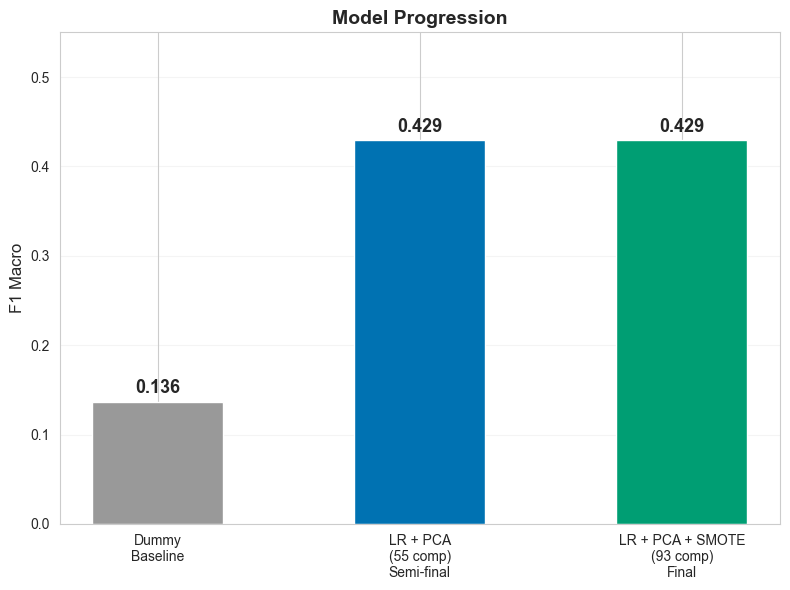

In [125]:
# --- 3 Models Comparison Plot ---

models = ['Dummy\nBaseline', 'LR + PCA\n(55 comp)\nSemi-final', 'LR + PCA + SMOTE\n(93 comp)\nFinal']
test_scores = [0.136, 0.429, 0.429]

fig, ax = plt.subplots(figsize=(8, 6))

bar_colors = ['#999999', '#0072B2', '#009E73']
bars = ax.bar(models, test_scores, color=bar_colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, test_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('F1 Macro', fontsize=12)
ax.set_title('Model Progression', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.55)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('../figures/03_model_progression.png', dpi=150, bbox_inches='tight')
plt.show()

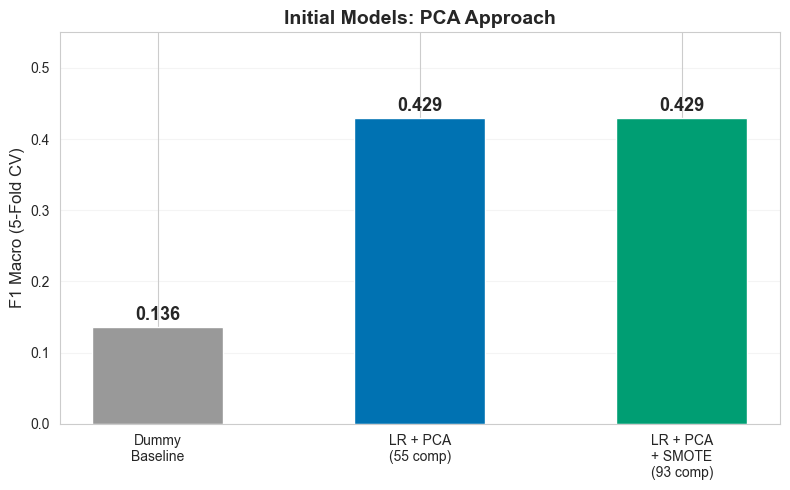

In [144]:
models = ['Dummy\nBaseline', 'LR + PCA\n(55 comp)', 'LR + PCA\n+ SMOTE\n(93 comp)']
test_scores = [0.136, 0.429, 0.429]
bar_colors = ['#999999', '#0072B2', '#009E73']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, test_scores, color=bar_colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, test_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('F1 Macro (5-Fold CV)', fontsize=12)
ax.set_title('Initial Models: PCA Approach', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.55)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('../figures/03_initial_models.png', dpi=150, bbox_inches='tight')
plt.show()

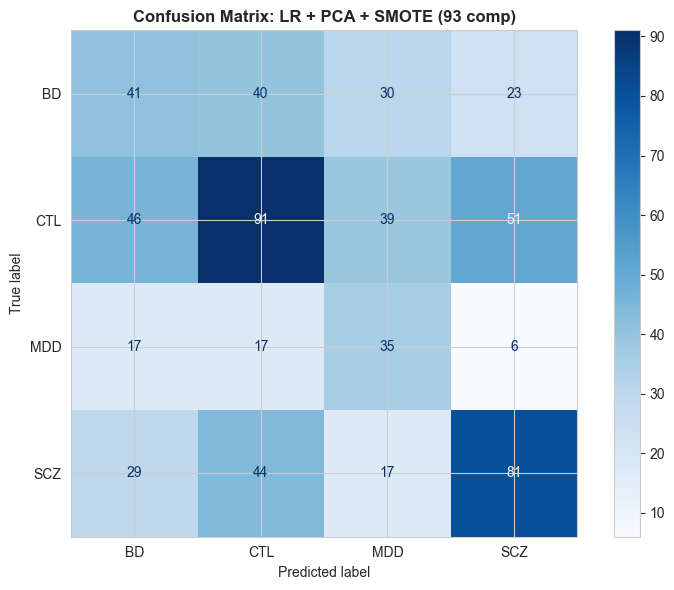

              precision    recall  f1-score   support

          BD       0.31      0.31      0.31       134
         CTL       0.47      0.40      0.43       227
         MDD       0.29      0.47      0.36        75
         SCZ       0.50      0.47      0.49       171

    accuracy                           0.41       607
   macro avg       0.39      0.41      0.40       607
weighted avg       0.42      0.41      0.41       607



In [129]:
# --- Confusion Matrix for final model ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_all = []
y_pred_all = []

pipeline_final = ImbPipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('pca', PCA(n_components=93)),
        ('log_reg', LogisticRegression(class_weight='balanced', max_iter=5000))
    ]
)

for train_idx, test_idx in cv.split(df[probe_cols], y_encoded, groups):
    pipeline_final.fit(df[probe_cols].iloc[train_idx], y_encoded[train_idx])
    y_pred = pipeline_final.predict(df[probe_cols].iloc[test_idx])
    y_true_all.extend(y_encoded[test_idx])
    y_pred_all.extend(y_pred)

cm = confusion_matrix(y_true_all, y_pred_all)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix: LR + PCA + SMOTE (93 comp)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/03_confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

from sklearn.metrics import classification_report
print(classification_report(y_true_all, y_pred_all, target_names=le.classes_))

In [153]:
# Check what PC1 correlates with in your data
import scipy.stats as stats

pca = PCA(n_components=2)
pcs = pca.fit_transform(df[probe_cols].values)

# PC1 vs age (only samples with age data)
age_mask = df['age'].notna()
r_age, p_age = stats.pearsonr(pcs[age_mask, 0], df.loc[age_mask, 'age'])
print(f"PC1 vs age: r={r_age:.3f}, p={p_age:.4f}")

# PC1 vs sex
sex_mask = df['sex'].notna()
from scipy.stats import pointbiserialr
sex_numeric = (df.loc[sex_mask, 'sex'] == 'M').astype(int)
r_sex, p_sex = pointbiserialr(sex_numeric, pcs[sex_mask, 0])
print(f"PC1 vs sex: r={r_sex:.3f}, p={p_sex:.4f}")

# PC1 vs diagnosis (ANOVA)
from scipy.stats import f_oneway
groups = [pcs[df['diagnosis']==d, 0] for d in ['SCZ','BD','MDD','CTL']]
f_diag, p_diag = f_oneway(*groups)
print(f"PC1 vs diagnosis: F={f_diag:.3f}, p={p_diag:.4f}")

# PC1 vs dataset (ANOVA)
ds_groups = [pcs[df['dataset']==d, 0] for d in df['dataset'].unique()]
f_ds, p_ds = f_oneway(*ds_groups)
print(f"PC1 vs dataset: F={f_ds:.3f}, p={p_ds:.4f}")

print(f"\nPC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")

PC1 vs age: r=0.043, p=0.3490
PC1 vs sex: r=0.003, p=0.9506
PC1 vs diagnosis: F=0.245, p=0.8648
PC1 vs dataset: F=0.076, p=0.9997

PC1 explains 35.4% of variance


In [154]:
# PC2 correlations
print("=== PC2 ===")
r_age2, p_age2 = stats.pearsonr(pcs[age_mask, 1], df.loc[age_mask, 'age'])
print(f"PC2 vs age: r={r_age2:.3f}, p={p_age2:.4f}")

r_sex2, p_sex2 = pointbiserialr(sex_numeric, pcs[sex_mask, 1])
print(f"PC2 vs sex: r={r_sex2:.3f}, p={p_sex2:.4f}")

f_diag2, p_diag2 = f_oneway(*[pcs[df['diagnosis']==d, 1] for d in ['SCZ','BD','MDD','CTL']])
print(f"PC2 vs diagnosis: F={f_diag2:.3f}, p={p_diag2:.4f}")

# Brain region
br_mask = df['brain_region'].notna()
br_groups = [pcs[df['brain_region']==br, 0] for br in df['brain_region'].dropna().unique()]
f_br, p_br = f_oneway(*br_groups)
print(f"\nPC1 vs brain_region: F={f_br:.3f}, p={p_br:.4f}")

br_groups2 = [pcs[df['brain_region']==br, 1] for br in df['brain_region'].dropna().unique()]
f_br2, p_br2 = f_oneway(*br_groups2)
print(f"PC2 vs brain_region: F={f_br2:.3f}, p={p_br2:.4f}")

# PMI
pmi_mask = df['pmi'].notna()
if pmi_mask.sum() > 10:
    r_pmi, p_pmi = stats.pearsonr(pcs[pmi_mask, 0], df.loc[pmi_mask, 'pmi'])
    print(f"\nPC1 vs PMI: r={r_pmi:.3f}, p={p_pmi:.4f}")
    r_pmi2, p_pmi2 = stats.pearsonr(pcs[pmi_mask, 1], df.loc[pmi_mask, 'pmi'])
    print(f"PC2 vs PMI: r={r_pmi2:.3f}, p={p_pmi2:.4f}")

print(f"\nPC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance")

=== PC2 ===
PC2 vs age: r=-0.134, p=0.0032
PC2 vs sex: r=0.136, p=0.0029
PC2 vs diagnosis: F=4.307, p=0.0051

PC1 vs brain_region: F=1269.496, p=0.0000
PC2 vs brain_region: F=10.612, p=0.0000

PC1 vs PMI: r=0.000, p=0.9985
PC2 vs PMI: r=0.018, p=0.6890

PC2 explains 6.8% of variance


In [107]:
# --- Quick test: SMOTE + LR on different probe counts ---

probe_sets = {
    '100 (5/5 folds)': [p for p, v in probe_votes.items() if v >= 5],
    '283 (4+ folds)': [p for p, v in probe_votes.items() if v >= 4],
    '758 (3+ folds)': [p for p, v in probe_votes.items() if v >= 3]
}

for name, probes in probe_sets.items():
    pipe = ImbPipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('log_reg', LogisticRegression(
                class_weight='balanced',
                max_iter=5000
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probes],
        y = y_encoded,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"SMOTE + LR ({name}) → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

SMOTE + LR (100 (5/5 folds)) → Train: 0.830, Test: 0.516
SMOTE + LR (283 (4+ folds)) → Train: 1.000, Test: 0.565
SMOTE + LR (758 (3+ folds)) → Train: 1.000, Test: 0.567


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(df['diagnosis'])


In [30]:
#XGBoost + PCA 
pipeline_pca_xgb = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('pca', PCA()),
        ('xgb', xgb.XGBClassifier(eval_metric='mlogloss', random_state=42))
    ]
)

param_grid_pca_xgb = {
    'pca__n_components': list(range(20, 100))
}

gscv_pca_xgb = GridSearchCV(
    estimator = pipeline_pca_xgb,
    param_grid = param_grid_pca_xgb,
    scoring = 'f1_macro',
    cv = cv
)

gscv_pca_xgb.fit(df[probe_cols], y_encoded, groups=groups)

print(gscv_pca_xgb.best_params_)
print(gscv_pca_xgb.best_score_)

{'pca__n_components': 28}
0.5448793960430042


In [35]:
cross_val_pca_xgb = cross_validate(
    estimator = gscv_pca_xgb.best_estimator_,
    X = df[probe_cols],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

cross_val_pca_xgb

{'fit_time': array([0.76775479, 0.75195384, 0.73505497, 0.82810211, 0.75571918]),
 'score_time': array([0.03471017, 0.03511119, 0.03469014, 0.09981012, 0.03441572]),
 'test_score': array([0.47663995, 0.52700982, 0.47963328, 0.48865559, 0.56870405]),
 'train_score': array([1., 1., 1., 1., 1.])}

In [49]:
# --- XGBoost : GridSearchCV  ---
#  Just XGBoost on all 10,678 probes.
# We tune parameters to limit memorization.

pipeline_xgb_tune = Pipeline(
    steps = [
        ('xgb', xgb.XGBClassifier(
            eval_metric='mlogloss',
            random_state=42
        ))
    ]
)

In [50]:
# --- Tune XGBoost parameters ---
# max_depth=2,3: shallow trees, less memorization
# n_estimators=20,50,100: fewer trees = less capacity
# min_child_weight=10,20: each leaf needs many samples
# colsample_bytree=0.3,0.5: each tree sees only 30-50% of probes
# subsample=0.7: each tree sees 70% of samples
# reg_alpha, reg_lambda: L1/L2 penalties on tree weights

param_grid_xgb_tune = {
    'xgb__max_depth': [2, 3],
    'xgb__n_estimators': [20, 50, 100],
    'xgb__min_child_weight': [10, 20],
    'xgb__colsample_bytree': [0.3, 0.5],
    'xgb__subsample': [0.7],
    'xgb__reg_alpha': [1.0, 5.0],
    'xgb__reg_lambda': [1.0, 5.0]
}

# 2 x 3 x 2 x 2 x 1 x 2 x 2 = 96 combinations x 5 folds = 480 fits
# Will take time on 10,678 probes
gscv_xgb_tune = GridSearchCV(
    estimator = pipeline_xgb_tune,
    param_grid = param_grid_xgb_tune,
    scoring = 'f1_macro',
    cv = cv
)

gscv_xgb_tune.fit(df[probe_cols], y_encoded, groups=groups)

print(gscv_xgb_tune.best_params_)
print(gscv_xgb_tune.best_score_)

{'xgb__colsample_bytree': 0.5, 'xgb__max_depth': 3, 'xgb__min_child_weight': 10, 'xgb__n_estimators': 100, 'xgb__reg_alpha': 1.0, 'xgb__reg_lambda': 5.0, 'xgb__subsample': 0.7}
0.5513113368524355


In [51]:
# --- Check XGBoost alone overfitting ---
cross_val_xgb_tune = cross_validate(
    estimator = gscv_xgb_tune.best_estimator_,
    X = df[probe_cols],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Train: {np.mean(cross_val_xgb_tune['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_xgb_tune['test_score']):.3f}")

Train: 1.000
Test:  0.551


In [36]:
# --- XGBoost + PCA: Tune components and model parameters together ---

# Pipeline: scale → reduce dimensions → classify
# XGBoost does not need scaling but PCA does, so scaler stays
pipeline_pca_xgb = Pipeline(
    steps = [
        ('scaler', StandardScaler()),          # Needed for PCA
        ('pca', PCA()),                        # Reduce dimensions
        ('xgb', xgb.XGBClassifier(
            eval_metric='mlogloss',            # Multi-class loss function
            random_state=42
        ))
    ]
)

# Test combinations of PCA components and XGBoost parameters
# max_depth: shallower trees = less overfitting
# colsample_bytree: % of features each tree sees (less = less overfitting)
param_grid_pca_xgb = {
    'pca__n_components': [20, 40, 60, 80],
    'xgb__max_depth': [2, 3, 4],
    'xgb__n_estimators': [100, 200],
    'xgb__learning_rate': [0.05, 0.1]
}

# GridSearchCV tests all 48 combinations (4 x 3 x 2 x 2)
# Each combination evaluated with 5-fold CV
gscv_pca_xgb = GridSearchCV(
    estimator = pipeline_pca_xgb,
    param_grid = param_grid_pca_xgb,
    scoring = 'f1_macro',
    cv = cv
)

# y_encoded because XGBoost needs numeric labels
gscv_pca_xgb.fit(df[probe_cols], y_encoded, groups=groups)

print(gscv_pca_xgb.best_params_)
print(gscv_pca_xgb.best_score_)

{'pca__n_components': 80, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 4, 'xgb__n_estimators': 200}
0.5171398334202703


In [37]:
# --- Check if overfitting is reduced ---
cross_val_pca_xgb = cross_validate(
    estimator = gscv_pca_xgb.best_estimator_,  # Best: PCA(80) + XGB(depth=4, lr=0.1, trees=200)
    X = df[probe_cols],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Train: {np.mean(cross_val_pca_xgb['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_pca_xgb['test_score']):.3f}")

Train: 1.000
Test:  0.514


In [38]:
# --- XGBoost + PCA: Force shallow trees to reduce overfitting ---
pipeline_pca_xgb2 = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('pca', PCA()),
        ('xgb', xgb.XGBClassifier(
            max_depth=2,                       # Very shallow trees, less memorization
            eval_metric='mlogloss',
            random_state=42
        ))
    ]
)

param_grid_pca_xgb2 = {
    'pca__n_components': [20, 40, 60, 80],
    'xgb__n_estimators': [50, 100, 200],
    'xgb__learning_rate': [0.05, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8],
    'xgb__colsample_bytree': [0.5, 0.7]
}

gscv_pca_xgb2 = GridSearchCV(
    estimator = pipeline_pca_xgb2,
    param_grid = param_grid_pca_xgb2,
    scoring = 'f1_macro',
    cv = cv
)

gscv_pca_xgb2.fit(df[probe_cols], y_encoded, groups=groups)

print(gscv_pca_xgb2.best_params_)
print(gscv_pca_xgb2.best_score_)

{'pca__n_components': 80, 'xgb__colsample_bytree': 0.5, 'xgb__learning_rate': 0.2, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}
0.5109809167200876


In [39]:
cross_val_pca_xgb2 = cross_validate(
    estimator = gscv_pca_xgb2.best_estimator_,
    X = df[probe_cols],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Train: {np.mean(cross_val_pca_xgb2['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_pca_xgb2['test_score']):.3f}")

Train: 1.000
Test:  0.464


In [40]:
results = pd.DataFrame(gscv_pca_xgb.cv_results_)
print(results[['param_pca__n_components', 'param_xgb__max_depth', 
               'param_xgb__learning_rate', 'param_xgb__n_estimators',
               'mean_test_score']].sort_values('mean_test_score', ascending=False).head(10).to_string())

   param_pca__n_components param_xgb__max_depth param_xgb__learning_rate param_xgb__n_estimators  mean_test_score
47                      80                    4                      0.1                     200         0.517140
22                      40                    4                      0.1                     100         0.516842
40                      80                    4                     0.05                     100         0.516196
4                       20                    4                     0.05                     100         0.515017
17                      40                    4                     0.05                     200         0.514803
16                      40                    4                     0.05                     100         0.511223
11                      20                    4                      0.1                     200         0.510714
29                      60                    4                     0.05                

In [46]:
# --- XGBoost + PCA: Strict regularization to reduce overfitting ---

# Pipeline: scale → reduce dimensions → classify
pipeline_pca_xgb_strict = Pipeline(
    steps = [
        ('scaler', StandardScaler()),          # Normalize probes (needed for PCA)
        ('pca', PCA()),                        # Reduce dimensions (GridSearchCV picks how many)
        ('xgb', xgb.XGBClassifier(
            eval_metric='mlogloss',            # Multi-class loss function
            random_state=42                    # Reproducible results
        ))
    ]
)

In [47]:
# --- Grid search with aggressive restrictions ---
# Every parameter is set to limit XGBoost's ability to memorize

param_grid_strict = {
    'pca__n_components': [30, 50, 80],         # Few PCA components (less input features)
    'xgb__max_depth': [2],                     # Very shallow trees (only 2 questions per tree)
    'xgb__n_estimators': [20, 50],             # Few trees (less capacity to memorize)
    'xgb__learning_rate': [0.3],               # High learning rate (learn fast, need fewer trees)
    'xgb__min_child_weight': [10, 20],         # Each leaf needs 10-20 samples minimum (prevents small splits)
    'xgb__subsample': [0.7],                   # Each tree sees only 70% of samples
    'xgb__colsample_bytree': [0.5],            # Each tree sees only 50% of features
    'xgb__reg_alpha': [1.0, 5.0],              # L1 penalty on tree weights (zeros out weak branches)
    'xgb__reg_lambda': [1.0, 5.0]              # L2 penalty on tree weights (shrinks all branches)
}

# Total: 3 x 1 x 2 x 1 x 2 x 1 x 1 x 2 x 2 = 48 combinations
# Each tested with 5-fold CV
gscv_strict = GridSearchCV(
    estimator = pipeline_pca_xgb_strict,
    param_grid = param_grid_strict,
    scoring = 'f1_macro',                      # Our evaluation metric
    cv = cv                                    # StratifiedGroupKFold (patient-aware)
)

# y_encoded because XGBoost needs numeric labels
gscv_strict.fit(df[probe_cols], y_encoded, groups=groups)

print(gscv_strict.best_params_)
print(gscv_strict.best_score_)

{'pca__n_components': 50, 'xgb__colsample_bytree': 0.5, 'xgb__learning_rate': 0.3, 'xgb__max_depth': 2, 'xgb__min_child_weight': 10, 'xgb__n_estimators': 50, 'xgb__reg_alpha': 1.0, 'xgb__reg_lambda': 1.0, 'xgb__subsample': 0.7}
0.46432927052963463


In [48]:
# --- Check if strict XGBoost + PCA reduced overfitting ---
cross_val_strict = cross_validate(
    estimator = gscv_strict.best_estimator_,
    X = df[probe_cols],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Train: {np.mean(cross_val_strict['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_strict['test_score']):.3f}")

Train: 0.890
Test:  0.418


In [ ]:
## PCA Results Summary

### Why PCA?
With 10,678 probes and only 607 samples, both LR and XGBoost overfit (train F1 = 1.0). PCA compresses features into fewer components to reduce the model's ability to memorize.

### LR + PCA
| Model | Components | C | Train F1 | Test F1 |
|---|---|---|---|---|
| LR baseline | 10,678 probes | 1.0 | 1.000 | 0.501 |
| LR + PCA (GridSearchCV) | 80 | 0.1 | 0.562 | 0.406 |

PCA fixed LR overfitting (train dropped from 1.000 to 0.562). But test F1 dropped from 0.501 to 0.406. The model stopped memorizing, but it also lost disease signal.

### XGBoost + PCA
| Model | Components | Train F1 | Test F1 |
|---|---|---|---|
| XGBoost baseline | 10,678 probes | 1.000 | 0.558 |
| XGBoost + PCA (GridSearchCV, depth=4) | 80 | 1.000 | 0.514 |
| XGBoost + PCA (GridSearchCV, depth=2) | 80 | 1.000 | 0.464 |
| XGBoost + PCA (strict regularization) | 50 | 0.890 | 0.418 |

XGBoost memorizes even with 20-80 PCA components (train=1.0). Only extreme restrictions (depth=2, 50 trees, high regularization) reduced train to 0.890, but test dropped to 0.418. Testing 20 to 80 components showed minimal difference (F1 range: 0.506-0.517), confirming the number of PCA components does not matter for this task.

### Why PCA Failed
PCA captures the directions of maximum variance in expression data. In brain gene expression, maximum variance comes from cell-type composition, tissue identity, and demographic factors, not from psychiatric disease. Published studies (Wang et al. 2018, PsychENCODE) show that cell-type proportions account for >88% of cross-population expression variation. Psychiatric disorders contribute less than 1-5% of total variance (Gandal et al. 2018, Science). PCA compresses all sources of variation into mixed components where the small disease signal gets diluted by the large non-disease variation.

### Conclusion
PCA reduces dimensions but keeps the wrong signal. It either:
- Fixes overfitting but loses disease signal (LR: test drops)
- Fails to fix overfitting entirely (XGBoost: train stays 1.0)
- Both problems at once (XGBoost strict: train drops but test drops more)

A supervised feature selection method that selects probes based on their relevance to disease classification is needed.

In [ ]:
#SMOTE+XGBOOST+PCA section

In [79]:
for n_comp in [20, 50, 80, 100]:
    pipe = ImbPipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_comp)),
            ('smote', SMOTE(random_state=42,k_neighbors=3)),
            
            ('xgb', xgb.XGBClassifier(
                max_depth=3, learning_rate=0.01,
                eval_metric='mlogloss', random_state=42
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probe_cols],
        y = y_encoded,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"PCA({n_comp}) + SMOTE + XGB → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

PCA(20) + SMOTE + XGB → Train: 0.665, Test: 0.434
PCA(50) + SMOTE + XGB → Train: 0.737, Test: 0.415
PCA(80) + SMOTE + XGB → Train: 0.750, Test: 0.428
PCA(100) + SMOTE + XGB → Train: 0.761, Test: 0.414


In [ ]:

    pipe = ImbPipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_comp)),
            ('smote', SMOTE(random_state=42,k_neightbers=3 )),
            
            ('xgb', xgb.XGBClassifier(
                n_estimators=25, max_depth=2, learning_rate=0.03,
                eval_metric='mlogloss', random_state=42
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probe_cols],
        y = y_encoded,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"PCA({n_comp}) + SMOTE + XGB → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

In [ ]:
## Feature Selection Summary

### LR Results
| Method | Best k | Train F1 | Test F1 |
|---|---|---|---|
| Baseline (no selection) | 10,678 | 1.000 | 0.501 |
| PCA (GridSearchCV) | 80 comp | 0.562 | 0.406 |

ANOVA improved LR by selecting probes that differ between classes, removing noise that LR cannot handle. PCA fixed overfitting but lost disease signal.

### XGBoost Results
| Method | Best k | Train F1 | Test F1 |
|---|---|---|---|
| Baseline (no selection) | 10,678 | 1.000 | 0.558 |
| PCA (GridSearchCV) | 80 comp | 1.000 | 0.517 |
| PCA strict (depth=2, regularized) | 50 comp | 0.890 | 0.418 |

No feature selection method improves XGBoost. All methods make it worse or give similar results. XGBoost baseline with all 10,678 probes gives the best test F1.


# SHAP Section:

In [ ]:
### Why we need SHAP
SHAP (SHapley Additive exPlanations) is the only feature selection approach that captures what XGBoost actually learned, 
including probe-probe interactions. 
Instead of guessing which probes might be useful (filter methods), SHAP reveals which probes the trained model actually uses.

Following the consensus nested cross-validation framework (Parvandeh et al. 2020, Bioinformatics), 
we apply SHAP per fold on training data only 
and keep probes that are consistently important across multiple folds (stable probes). 
This approach:
1. Captures non-linear interactions between probes
2. Avoids data leakage (SHAP computed on training data only per fold)
3. Filters out noise through majority vote across folds
4. Preserves biological interpretability (original probe names retained)

In [ ]:
## Step 6: SHAP Stable Probe Selection

SHAP computes a contribution score for each probe, for each sample, for each class. We use TreeExplainer which is exact for tree-based models (Lundberg et al. 2020, Nature Machine Intelligence).

To avoid data leakage, we follow the consensus nested cross-validation framework (Parvandeh et al. 2020, Bioinformatics):

1. In each CV fold, train XGBoost on training data only
2. Compute SHAP on training data only
3. Select top-ranked probes per fold
4. Keep only probes that 3+ folds agree on (majority vote)
5. Evaluate the stable probes with cross_validate

The overfit XGBoost model (train=1.0) captures both real biology and noise. The majority vote filter removes the noise because memorized probes change from fold to fold. Real probes stay consistent across folds.

In [10]:
import shap

In [11]:
# --- Stable Probe Selection (no arbitrary threshold) ---
# Rule: In each fold, keep all probes with SHAP importance above the mean
# The number of probes selected is determined by the data, not by us
# Majority vote (3+ folds) keeps only consistent probes

from collections import Counter

probes_per_fold = []
probes_per_fold_count = []

for fold_num, (train_idx, test_idx) in enumerate(cv.split(df[probe_cols], y_encoded, groups)):
    
    # Train XGBoost on training data only
    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        eval_metric='mlogloss', random_state=42
    )
    model.fit(df[probe_cols].iloc[train_idx], y_encoded[train_idx])
    
    # Compute SHAP on training data only
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(df[probe_cols].iloc[train_idx])
    mean_shap = np.mean(np.abs(shap_vals), axis=(0, 2))
    
    # Keep probes with SHAP above the mean (data-driven threshold)
    threshold = np.mean(mean_shap)
    above_mean = np.where(mean_shap > threshold)[0]
    top_probes = df[probe_cols].columns[above_mean].tolist()
    probes_per_fold.extend(top_probes)
    probes_per_fold_count.append(len(top_probes))
    
    print(f"Fold {fold_num + 1}: {len(top_probes)} probes above mean SHAP")

# Majority vote: keep probes that 3+ folds agree on
probe_votes = Counter(probes_per_fold)
stable_probes = [p for p, votes in probe_votes.items() if votes >= 3]

print(f"\nProbes per fold: {probes_per_fold_count}")
print(f"Stable probes (3+ folds): {len(stable_probes)}")

Fold 1: 1595 probes above mean SHAP
Fold 2: 1597 probes above mean SHAP
Fold 3: 1634 probes above mean SHAP
Fold 4: 1637 probes above mean SHAP
Fold 5: 1665 probes above mean SHAP

Probes per fold: [1595, 1597, 1634, 1637, 1665]
Stable probes (3+ folds): 758


In [12]:
# --- Evaluate stable probes (758) with cross_validate ---

cross_val_shap_xgb = cross_validate(
    estimator = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        eval_metric='mlogloss', random_state=42
    ),
    X = df[stable_probes],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"XGBoost + Stable SHAP ({len(stable_probes)} probes)")
print(f"Train: {np.mean(cross_val_shap_xgb['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_shap_xgb['test_score']):.3f}")

XGBoost + Stable SHAP (758 probes)
Train: 1.000
Test:  0.696


In [14]:
# --- SMOTE + Stable SHAP Probes ---
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipeline_smote_xgb = ImbPipeline(
    steps = [
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.1,
            eval_metric='mlogloss',
            random_state=42
        ))
    ]
)

cross_val_smote_xgb = cross_validate(
    estimator = pipeline_smote_xgb,
    X = df[stable_probes],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"XGBoost + Stable SHAP + SMOTE ({len(stable_probes)} probes)")
print(f"Train: {np.mean(cross_val_smote_xgb['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_smote_xgb['test_score']):.3f}")

XGBoost + Stable SHAP + SMOTE (758 probes)
Train: 1.000
Test:  0.703


In [15]:
# --- Reduce overfitting on stable probes + SMOTE ---
# Now we have 758 probes (not 10,678)
# Shallower trees might work here without losing signal

from sklearn.model_selection import GridSearchCV

pipeline_smote_xgb_tune = ImbPipeline(
    steps = [
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb.XGBClassifier(
            eval_metric='mlogloss',
            random_state=42
        ))
    ]
)

param_grid_smote_xgb = {
    'xgb__max_depth': [2, 3],
    'xgb__n_estimators': [50, 100],
    'xgb__learning_rate': [0.1, 0.2],
    'xgb__min_child_weight': [10, 20],
    'xgb__subsample': [0.7, 0.8],
    'xgb__colsample_bytree': [0.5, 0.7]
}

# 2x2x2x2x2x2 = 64 combinations x 5 folds
gscv_smote_xgb = GridSearchCV(
    estimator = pipeline_smote_xgb_tune,
    param_grid = param_grid_smote_xgb,
    scoring = 'f1_macro',
    cv = cv
)

gscv_smote_xgb.fit(df[stable_probes], y_encoded, groups=groups)

print(gscv_smote_xgb.best_params_)
print(gscv_smote_xgb.best_score_)

{'xgb__colsample_bytree': 0.5, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 3, 'xgb__min_child_weight': 10, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
0.7094651861692294


In [16]:
cross_val_final = cross_validate(
    estimator = gscv_smote_xgb.best_estimator_,
    X = df[stable_probes],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Train: {np.mean(cross_val_final['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_final['test_score']):.3f}")

Train: 1.000
Test:  0.709


In [127]:
# --- Extreme XGBoost on 758 probes ---
stable_758 = pd.read_csv('../data/stable_probes_758.csv')['0'].tolist()

pipeline_extreme_758 = ImbPipeline(
    steps = [
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb.XGBClassifier(
            max_depth=1,
            n_estimators=20,
            learning_rate=0.3,
            min_child_weight=50,
            subsample=0.5,
            colsample_bytree=0.3,
            reg_alpha=10.0,
            reg_lambda=10.0,
            eval_metric='mlogloss',
            random_state=42
        ))
    ]
)

cross_val_758 = cross_validate(
    estimator = pipeline_extreme_758,
    X = df[stable_758],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Extreme XGB + SMOTE (758 probes) - Train: {np.mean(cross_val_758['train_score']):.3f}, Test: {np.mean(cross_val_758['test_score']):.3f}")

Extreme XGB + SMOTE (758 probes) - Train: 0.596, Test: 0.492


In [136]:
# ---  XGBoost on 758 probes+pca ---
stable_758 = pd.read_csv('../data/stable_probes_758.csv')['0'].tolist()

pipeline_extreme_758 = ImbPipeline(
    steps = [
        ('smote', SMOTE(random_state=42)),
        ('pca',PCA(n_components=100)),
        ('xgb', xgb.XGBClassifier(
        )
        )
    
    ]
)

cross_val_758 = cross_validate(
    estimator = pipeline_extreme_758,
    X = df[stable_758],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Extreme XGB + SMOTE (758 probes) - Train: {np.mean(cross_val_758['train_score']):.3f}, Test: {np.mean(cross_val_758['test_score']):.3f}")

Extreme XGB + SMOTE (758 probes) - Train: 1.000, Test: 0.552


In [128]:
# --- Adjusted XGBoost: use more probes but stay controlled ---

configs = [
    {'max_depth': 2, 'n_estimators': 15, 'colsample_bytree': 0.5, 'min_child_weight': 20},
    {'max_depth': 2, 'n_estimators': 20, 'colsample_bytree': 0.7, 'min_child_weight': 20},
    {'max_depth': 2, 'n_estimators': 25, 'colsample_bytree': 0.8, 'min_child_weight': 15},
    {'max_depth': 3, 'n_estimators': 15, 'colsample_bytree': 0.5, 'min_child_weight': 20},
]

for cfg in configs:
    pipe = ImbPipeline(
        steps = [
            ('smote', SMOTE(random_state=42)),
            ('xgb', xgb.XGBClassifier(
                learning_rate=0.3,
                subsample=0.7,
                reg_alpha=5.0,
                reg_lambda=5.0,
                eval_metric='mlogloss',
                random_state=42,
                **cfg
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[stable_758],
        y = y_encoded,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"depth={cfg['max_depth']}, trees={cfg['n_estimators']}, col={cfg['colsample_bytree']}, mcw={cfg['min_child_weight']} → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

depth=2, trees=15, col=0.5, mcw=20 → Train: 0.811, Test: 0.574
depth=2, trees=20, col=0.7, mcw=20 → Train: 0.852, Test: 0.599
depth=2, trees=25, col=0.8, mcw=15 → Train: 0.895, Test: 0.604
depth=3, trees=15, col=0.5, mcw=20 → Train: 0.864, Test: 0.584


In [17]:
# --- Extreme restriction: depth=1, 20 trees ---
# This is the absolute minimum complexity for XGBoost
# Each tree asks only 1 question (a stump)

pipeline_extreme = ImbPipeline(
    steps = [
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb.XGBClassifier(
            max_depth=1,
            n_estimators=20,
            learning_rate=0.3,
            min_child_weight=50,
            subsample=0.5,
            colsample_bytree=0.3,
            reg_alpha=10.0,
            reg_lambda=10.0,
            eval_metric='mlogloss',
            random_state=42
        ))
    ]
)

cross_val_extreme = cross_validate(
    estimator = pipeline_extreme,
    X = df[stable_probes],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Train: {np.mean(cross_val_extreme['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_extreme['test_score']):.3f}")

Train: 0.596
Test:  0.492


In [106]:
pipeline_extreme_all = ImbPipeline(
    steps = [
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb.XGBClassifier(
            max_depth=1,
            n_estimators=20,
            learning_rate=0.3,
            min_child_weight=50,
            subsample=0.5,
            colsample_bytree=0.3,
            reg_alpha=10.0,
            reg_lambda=10.0,
            eval_metric='mlogloss',
            random_state=42
        ))
    ]
)

cross_val_extreme_all = cross_validate(
    estimator = pipeline_extreme_all,
    X = df[probe_cols],
    y = y_encoded,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Extreme XGB + SMOTE (all probes) - Train: {np.mean(cross_val_extreme_all['train_score']):.3f}, Test: {np.mean(cross_val_extreme_all['test_score']):.3f}")

Extreme XGB + SMOTE (all probes) - Train: 0.589, Test: 0.453


In [18]:
# --- SVM + Stable SHAP Probes ---
from sklearn.svm import SVC

pipeline_svm = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', class_weight='balanced'))
    ]
)

cross_val_svm = cross_validate(
    estimator = pipeline_svm,
    X = df[stable_probes],
    y = df['diagnosis'],
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"SVM + Stable SHAP ({len(stable_probes)} probes)")
print(f"Train: {np.mean(cross_val_svm['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_svm['test_score']):.3f}")

SVM + Stable SHAP (758 probes)
Train: 0.785
Test:  0.475


In [19]:
# --- SVM + Stable SHAP: Tune parameters ---
pipeline_svm_tune = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('svm', SVC(class_weight='balanced'))
    ]
)

# C: higher = more flexible, lower = stricter
# gamma: higher = tighter decision boundary, lower = smoother
param_grid_svm = {
    'svm__C': [0.1, 1.0, 10.0, 50.0],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01],
    'svm__kernel': ['rbf']
}

gscv_svm = GridSearchCV(
    estimator = pipeline_svm_tune,
    param_grid = param_grid_svm,
    scoring = 'f1_macro',
    cv = cv
)

gscv_svm.fit(df[stable_probes], df['diagnosis'], groups=groups)

print(gscv_svm.best_params_)
print(gscv_svm.best_score_)

{'svm__C': 50.0, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
0.598020749652306


In [20]:
cross_val_svm_tune = cross_validate(
    estimator = gscv_svm.best_estimator_,
    X = df[stable_probes],
    y = df['diagnosis'],
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Train: {np.mean(cross_val_svm_tune['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_svm_tune['test_score']):.3f}")

Train: 1.000
Test:  0.598


In [21]:
results = pd.DataFrame(gscv_svm.cv_results_)
print(results[['param_svm__C', 'param_svm__gamma', 'mean_test_score']].sort_values('mean_test_score', ascending=False).head(10).to_string())

    param_svm__C param_svm__gamma  mean_test_score
14          50.0            0.001         0.598021
10          10.0            0.001         0.589286
12          50.0            scale         0.579259
13          50.0             auto         0.579259
8           10.0            scale         0.572186
9           10.0             auto         0.572186
6            1.0            0.001         0.478113
4            1.0            scale         0.474597
5            1.0             auto         0.474597
7            1.0             0.01         0.340803


In [22]:
# --- LR + Stable SHAP Probes ---
pipeline_lr_shap = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('log_reg', LogisticRegression(
            class_weight='balanced',
            max_iter=5000
        ))
    ]
)

cross_val_lr_shap = cross_validate(
    estimator = pipeline_lr_shap,
    X = df[stable_probes],
    y = df['diagnosis'],
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"LR + Stable SHAP ({len(stable_probes)} probes)")
print(f"Train: {np.mean(cross_val_lr_shap['train_score']):.3f}")
print(f"Test:  {np.mean(cross_val_lr_shap['test_score']):.3f}")

LR + Stable SHAP (758 probes)
Train: 1.000
Test:  0.566


In [23]:
# --- LR + Stable SHAP: Tune C ---
pipeline_lr_shap_tune = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('log_reg', LogisticRegression(
            class_weight='balanced',
            max_iter=5000
        ))
    ]
)

param_grid_lr_shap = {
    'log_reg__C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
}

gscv_lr_shap = GridSearchCV(
    estimator = pipeline_lr_shap_tune,
    param_grid = param_grid_lr_shap,
    scoring = 'f1_macro',
    cv = cv
)

gscv_lr_shap.fit(df[stable_probes], df['diagnosis'], groups=groups)

print(gscv_lr_shap.best_params_)
print(gscv_lr_shap.best_score_)

{'log_reg__C': 1.0}
0.5655960947746754


In [24]:
results = pd.DataFrame(gscv_lr_shap.cv_results_)
print(results[['param_log_reg__C', 'mean_test_score']].to_string())

   param_log_reg__C  mean_test_score
0             0.001         0.495719
1             0.005         0.540411
2             0.010         0.537292
3             0.050         0.542857
4             0.100         0.552281
5             0.500         0.559279
6             1.000         0.565596


In [25]:
pipeline_lr_c005 = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('log_reg', LogisticRegression(
            class_weight='balanced',
            C=0.05,
            max_iter=5000
        ))
    ]
)

cross_val_lr_c005 = cross_validate(
    estimator = pipeline_lr_c005,
    X = df[stable_probes],
    y = df['diagnosis'],
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"C=0.05 - Train: {np.mean(cross_val_lr_c005['train_score']):.3f}, Test: {np.mean(cross_val_lr_c005['test_score']):.3f}")

C=0.05 - Train: 1.000, Test: 0.543


In [26]:
pipeline_lr_c0001 = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('log_reg', LogisticRegression(
            class_weight='balanced',
            C=0.001,
            max_iter=5000
        ))
    ]
)

cross_val_lr_c0001 = cross_validate(
    estimator = pipeline_lr_c0001,
    X = df[stable_probes],
    y = df['diagnosis'],
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"C=0.001 - Train: {np.mean(cross_val_lr_c0001['train_score']):.3f}, Test: {np.mean(cross_val_lr_c0001['test_score']):.3f}")

C=0.001 - Train: 0.745, Test: 0.496


In [27]:
for c_val in [0.002, 0.003, 0.005, 0.007, 0.01]:
    pipe = Pipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(
                class_weight='balanced',
                C=c_val,
                max_iter=5000
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[stable_probes],
        y = df['diagnosis'],
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"C={c_val:.3f} - Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

C=0.002 - Train: 0.824, Test: 0.530
C=0.003 - Train: 0.865, Test: 0.533
C=0.005 - Train: 0.922, Test: 0.540
C=0.007 - Train: 0.950, Test: 0.541
C=0.010 - Train: 0.965, Test: 0.537


In [28]:
# --- Test stricter majority vote thresholds ---
# Current: 3+ folds (758 probes)
# Test: 4+ folds and 5/5 folds

for min_folds in [3, 4, 5]:
    strict_probes = [p for p, votes in probe_votes.items() if votes >= min_folds]
    
    cv_result = cross_validate(
        estimator = xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.1,
            eval_metric='mlogloss', random_state=42),
        X = df[strict_probes],
        y = y_encoded,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"{min_folds}+ folds → {len(strict_probes)} probes → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

3+ folds → 758 probes → Train: 1.000, Test: 0.696
4+ folds → 283 probes → Train: 1.000, Test: 0.696
5+ folds → 100 probes → Train: 1.000, Test: 0.716


In [29]:
# --- Test LR model on 100 most stable probes (5/5 folds) ---

probes_5folds = [p for p, votes in probe_votes.items() if votes >= 5]

# LR
for c_val in [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]:
    pipe = Pipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(
                class_weight='balanced',
                C=c_val,
                max_iter=5000
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probes_5folds],
        y = df['diagnosis'],
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"LR C={c_val:.3f} → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

LR C=0.001 → Train: 0.567, Test: 0.493
LR C=0.005 → Train: 0.637, Test: 0.539
LR C=0.010 → Train: 0.687, Test: 0.550
LR C=0.050 → Train: 0.766, Test: 0.555
LR C=0.100 → Train: 0.779, Test: 0.546
LR C=0.500 → Train: 0.815, Test: 0.523
LR C=1.000 → Train: 0.826, Test: 0.513


In [30]:
# --- SMOTE + LR on 100 most stable probes ---

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

for c_val in [0.005, 0.01, 0.05, 0.1, 0.5]:
    pipe = ImbPipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('log_reg', LogisticRegression(
                class_weight='balanced',
                C=c_val,
                max_iter=5000
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probes_5folds],
        y = df['diagnosis'],
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"SMOTE + LR C={c_val:.3f} → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

SMOTE + LR C=0.005 → Train: 0.654, Test: 0.510
SMOTE + LR C=0.010 → Train: 0.699, Test: 0.536
SMOTE + LR C=0.050 → Train: 0.764, Test: 0.529
SMOTE + LR C=0.100 → Train: 0.779, Test: 0.531
SMOTE + LR C=0.500 → Train: 0.822, Test: 0.521


In [34]:
# --- XGBoost on 100 probes: very few trees ---

for n_trees in [5, 10, 15, 20, 30, 50]:
    pipe = xgb.XGBClassifier(
        n_estimators=n_trees,
        max_depth=2,
        learning_rate=0.3,
        eval_metric='mlogloss',
        random_state=42
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probes_5folds],
        y = y_encoded,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"Trees={n_trees}, depth=2 → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

Trees=5, depth=2 → Train: 0.691, Test: 0.516
Trees=10, depth=2 → Train: 0.844, Test: 0.592
Trees=15, depth=2 → Train: 0.914, Test: 0.621
Trees=20, depth=2 → Train: 0.953, Test: 0.649
Trees=30, depth=2 → Train: 0.983, Test: 0.671
Trees=50, depth=2 → Train: 0.999, Test: 0.681


In [35]:
for n_trees in [12, 15, 18, 20, 22, 25]:
    pipe = xgb.XGBClassifier(
        n_estimators=n_trees,
        max_depth=2,
        learning_rate=0.3,
        subsample=0.8,
        colsample_bytree=0.7,
        eval_metric='mlogloss',
        random_state=42
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probes_5folds],
        y = y_encoded,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"Trees={n_trees}, depth=2 → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

Trees=12, depth=2 → Train: 0.855, Test: 0.596
Trees=15, depth=2 → Train: 0.890, Test: 0.621
Trees=18, depth=2 → Train: 0.916, Test: 0.631
Trees=20, depth=2 → Train: 0.931, Test: 0.635
Trees=22, depth=2 → Train: 0.943, Test: 0.643
Trees=25, depth=2 → Train: 0.960, Test: 0.637


In [36]:
# --- SMOTE + XGBoost (20 trees, depth=2) on 100 probes ---

for n_trees in [15, 20, 25, 30]:
    pipe = ImbPipeline(
        steps = [
            ('smote', SMOTE(random_state=42)),
            ('xgb', xgb.XGBClassifier(
                n_estimators=n_trees,
                max_depth=2,
                learning_rate=0.3,
                eval_metric='mlogloss',
                random_state=42
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probes_5folds],
        y = y_encoded,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"SMOTE + Trees={n_trees}, depth=2 → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

SMOTE + Trees=15, depth=2 → Train: 0.880, Test: 0.630
SMOTE + Trees=20, depth=2 → Train: 0.918, Test: 0.661
SMOTE + Trees=25, depth=2 → Train: 0.946, Test: 0.674
SMOTE + Trees=30, depth=2 → Train: 0.961, Test: 0.676


In [37]:
# --- Top N probes sorted by vote count ---

sorted_probes = sorted(probe_votes.items(), key=lambda x: x[1], reverse=True)

for n_probes in [20, 30, 50]:
    top_probes = [p for p, v in sorted_probes[:n_probes]]
    
    # XGBoost restricted
    for n_trees in [15, 20]:
        pipe = xgb.XGBClassifier(
            n_estimators=n_trees,
            max_depth=2,
            learning_rate=0.3,
            eval_metric='mlogloss',
            random_state=42
        )
        
        cv_result = cross_validate(
            estimator = pipe,
            X = df[top_probes],
            y = y_encoded,
            groups = groups,
            scoring = 'f1_macro',
            cv = cv,
            return_train_score = True
        )
        
        print(f"XGB Trees={n_trees}, {n_probes} probes → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")
    print()

XGB Trees=15, 20 probes → Train: 0.768, Test: 0.522
XGB Trees=20, 20 probes → Train: 0.821, Test: 0.540

XGB Trees=15, 30 probes → Train: 0.811, Test: 0.538
XGB Trees=20, 30 probes → Train: 0.861, Test: 0.540

XGB Trees=15, 50 probes → Train: 0.852, Test: 0.563
XGB Trees=20, 50 probes → Train: 0.896, Test: 0.570



In [38]:
for n_trees in [25, 28, 30, 35]:
    pipe = ImbPipeline(
        steps = [
            ('smote', SMOTE(random_state=42)),
            ('xgb', xgb.XGBClassifier(
                n_estimators=n_trees,
                max_depth=2,
                learning_rate=0.2,
                eval_metric='mlogloss',
                random_state=42
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probes_5folds],
        y = y_encoded,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"SMOTE + Trees={n_trees}, depth=2, lr=0.2 → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

SMOTE + Trees=25, depth=2, lr=0.2 → Train: 0.888, Test: 0.642
SMOTE + Trees=28, depth=2, lr=0.2 → Train: 0.905, Test: 0.646
SMOTE + Trees=30, depth=2, lr=0.2 → Train: 0.914, Test: 0.664
SMOTE + Trees=35, depth=2, lr=0.2 → Train: 0.938, Test: 0.660


In [39]:
for reg in [0.5, 1.0, 2.0, 5.0]:
    pipe = ImbPipeline(
        steps = [
            ('smote', SMOTE(random_state=42)),
            ('xgb', xgb.XGBClassifier(
                n_estimators=25,
                max_depth=2,
                learning_rate=0.3,
                reg_alpha=reg,
                reg_lambda=reg,
                eval_metric='mlogloss',
                random_state=42
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[probes_5folds],
        y = y_encoded,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"SMOTE + 25 trees, reg={reg} → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

SMOTE + 25 trees, reg=0.5 → Train: 0.942, Test: 0.645
SMOTE + 25 trees, reg=1.0 → Train: 0.935, Test: 0.639
SMOTE + 25 trees, reg=2.0 → Train: 0.924, Test: 0.663
SMOTE + 25 trees, reg=5.0 → Train: 0.889, Test: 0.635


In [40]:
# Save the 100 most stable probes (5/5 folds)
probes_5folds = [p for p, votes in probe_votes.items() if votes >= 5]
pd.Series(probes_5folds).to_csv('../data/stable_probes_100.csv', index=False)
print(f"Saved {len(probes_5folds)} probes to ../data/stable_probes_100.csv")

# Also save the 758 probes (3+ folds)
pd.Series(stable_probes).to_csv('../data/stable_probes_758.csv', index=False)
print(f"Saved {len(stable_probes)} probes to ../data/stable_probes_758.csv")

Saved 100 probes to ../data/stable_probes_100.csv
Saved 758 probes to ../data/stable_probes_758.csv


# SHAP Section for Genes Analysis:


In [41]:
# --- SHAP Biological Interpretation on 100 Stable Probes ---
# Train one model on full data for interpretation only
# This is NOT for reporting scores, only for understanding which genes matter

probes_5folds = [p for p, votes in probe_votes.items() if votes >= 5]

model_interp = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    eval_metric='mlogloss', random_state=42
)
model_interp.fit(df[probes_5folds], y_encoded)

explainer = shap.TreeExplainer(model_interp)
shap_vals = explainer.shap_values(df[probes_5folds])

# Average absolute SHAP across all samples and all classes
mean_shap = np.mean(np.abs(shap_vals), axis=(0, 2))

# Top 20 probes by SHAP importance
top20_idx = np.argsort(mean_shap)[::-1][:20]
top20_probes = [probes_5folds[i] for i in top20_idx]
top20_shap = mean_shap[top20_idx]

print("Top 20 probes by SHAP importance:")
for i, (probe, shap_val) in enumerate(zip(top20_probes, top20_shap)):
    print(f"{i+1:2d}. {probe:20s} SHAP: {shap_val:.4f}")

Top 20 probes by SHAP importance:
 1. 213479_at            SHAP: 0.1549
 2. 202917_s_at          SHAP: 0.1449
 3. 218515_at            SHAP: 0.1320
 4. 202203_s_at          SHAP: 0.1295
 5. 211126_s_at          SHAP: 0.1260
 6. 202747_s_at          SHAP: 0.1222
 7. 207766_at            SHAP: 0.1218
 8. 204748_at            SHAP: 0.1199
 9. 216674_at            SHAP: 0.1192
10. 217275_at            SHAP: 0.1180
11. 219725_at            SHAP: 0.1166
12. 206108_s_at          SHAP: 0.1136
13. 204670_x_at          SHAP: 0.1112
14. 220330_s_at          SHAP: 0.1096
15. 203987_at            SHAP: 0.1076
16. 215606_s_at          SHAP: 0.1059
17. 217911_s_at          SHAP: 0.1048
18. 205048_s_at          SHAP: 0.1032
19. 219642_s_at          SHAP: 0.1023
20. 210611_s_at          SHAP: 0.0989


In [44]:
print(os.listdir('../data/raw/'))

['GSE17612_series_matrix.txt', 'GSE5389_series_matrix.txt', 'GSE21138_series_matrix.txt', 'GSE5388_series_matrix.txt', 'study2', 'GSE53987_series_matrix.txt.gz', 'GSE21935_series_matrix.txt', 'GPL96.annot.gz', 'GSE54568_series_matrix.txt', '.ipynb_checkpoints', 'GSE12649_series_matrix.txt']


In [46]:
# Check first few lines of the file
with open('../data/raw/GPL96.annot.gz', 'r') as f:
    for i in range(5):
        print(f.readline().strip())

<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
"http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" lang="en" xml:lang="en">
<head>


In [49]:
#import urllib.request
url = 'https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL96/annot/GPL96.annot.gz'
urllib.request.urlretrieve(url, '../data/raw/GPL96_annotation.gz')
print("Downloaded")

Downloaded


In [52]:
annot = pd.read_csv('../data/raw/GPL96_annotation.gz',
                     compression='gzip',
                     sep='\t',
                     skiprows=27,
                     low_memory=False)

print(annot.columns.tolist())
print(annot.shape)
print(annot[['ID', 'Gene symbol']].head())

['ID', 'Gene title', 'Gene symbol', 'Gene ID', 'UniGene title', 'UniGene symbol', 'UniGene ID', 'Nucleotide Title', 'GI', 'GenBank Accession', 'Platform_CLONEID', 'Platform_ORF', 'Platform_SPOTID', 'Chromosome location', 'Chromosome annotation', 'GO:Function', 'GO:Process', 'GO:Component', 'GO:Function ID', 'GO:Process ID', 'GO:Component ID']
(22284, 21)
          ID     Gene symbol
0  1007_s_at  MIR4640///DDR1
1    1053_at            RFC2
2     117_at           HSPA6
3     121_at            PAX8
4  1255_g_at          GUCA1A


In [53]:
# --- Map top 20 probes to gene symbols ---

# Create probe-to-gene dictionary
probe_to_gene = dict(zip(annot['ID'], annot['Gene symbol']))

# Map top 20 probes
top20_idx = np.argsort(mean_shap)[::-1][:20]

print("Top 20 probes by SHAP importance:")
print(f"{'Rank':<5} {'Probe':<20} {'Gene':<25} {'SHAP':<10}")
print("-" * 60)

for i, idx in enumerate(top20_idx):
    probe = probes_5folds[idx]
    gene = probe_to_gene.get(probe, 'Unknown')
    shap_val = mean_shap[idx]
    print(f"{i+1:<5} {probe:<20} {gene:<25} {shap_val:.4f}")

Top 20 probes by SHAP importance:
Rank  Probe                Gene                      SHAP      
------------------------------------------------------------
1     213479_at            NPTX2                     0.1549
2     202917_s_at          S100A8                    0.1449
3     218515_at            PAXBP1                    0.1320
4     202203_s_at          AMFR                      0.1295
5     211126_s_at          CSRP2                     0.1260
6     202747_s_at          ITM2A                     0.1222
7     207766_at            CDKL1                     0.1218
8     204748_at            PTGS2                     0.1199
9     216674_at            HES2                      0.1192
10    217275_at            TSSK2                     0.1180
11    219725_at            TREM2                     0.1166
12    206108_s_at          SRSF6                     0.1136
13    204670_x_at          LOC100996809///HLA-DRB4///HLA-DRB1 0.1112
14    220330_s_at          SAMSN1                   

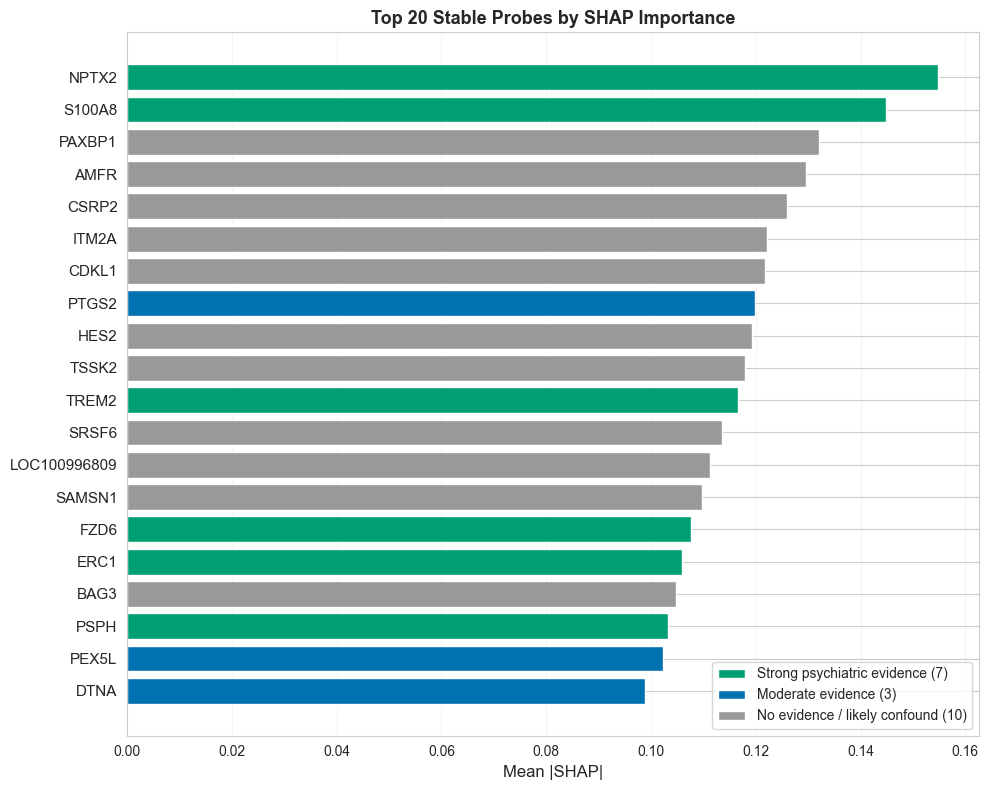

In [54]:
# --- Top 20 Genes by SHAP Importance ---

probes_5folds = [p for p, votes in probe_votes.items() if votes >= 5]
top20_idx = np.argsort(mean_shap)[::-1][:20]

# Map probes to gene names
probe_to_gene = dict(zip(annot['ID'], annot['Gene symbol']))
gene_names = []
shap_values_top20 = []

for idx in top20_idx:
    probe = probes_5folds[idx]
    gene = probe_to_gene.get(probe, probe)
    # Shorten long names
    if '///' in str(gene):
        gene = gene.split('///')[0]
    gene_names.append(gene)
    shap_values_top20.append(mean_shap[idx])

# Color by evidence category
colors = []
strong = ['NPTX2', 'S100A8', 'TREM2', 'HLA-DRB1', 'FZD6', 'ERC1', 'PSPH']
moderate = ['PTGS2', 'PEX5L', 'DTNA']

for gene in gene_names:
    if gene in strong:
        colors.append('#009E73')      # Green = strong psychiatric evidence
    elif gene in moderate:
        colors.append('#0072B2')      # Blue = moderate evidence
    else:
        colors.append('#999999')      # Grey = no evidence / confound

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(gene_names) - 1, -1, -1)
ax.barh(y_pos, shap_values_top20, color=colors, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(gene_names, fontsize=11)
ax.set_xlabel('Mean |SHAP|', fontsize=12)
ax.set_title('Top 20 Stable Probes by SHAP Importance', fontsize=13, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#009E73', label='Strong psychiatric evidence (7)'),
    Patch(facecolor='#0072B2', label='Moderate evidence (3)'),
    Patch(facecolor='#999999', label='No evidence / likely confound (10)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('../figures/03_shap_top20_genes.png', dpi=150, bbox_inches='tight')
plt.show()

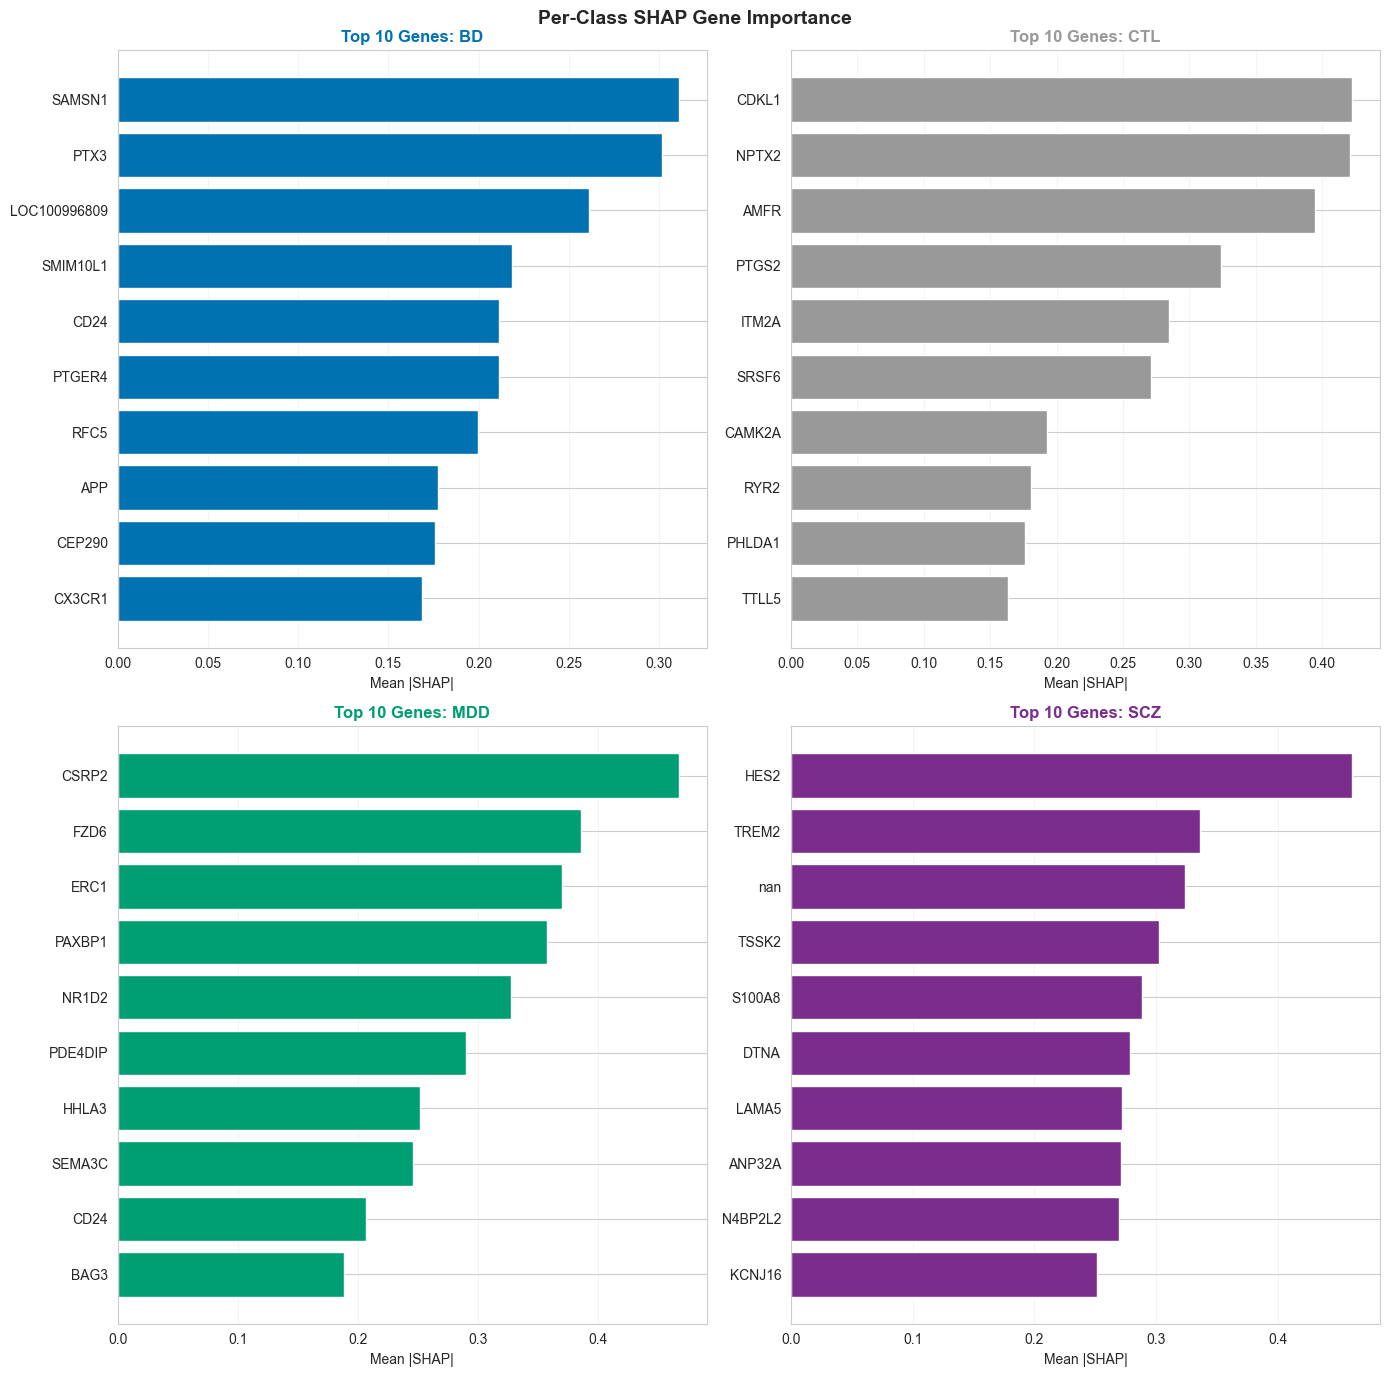

In [58]:
# --- Per-Class SHAP Importance (Fixed axis order) ---
# shap_vals shape: (607 samples, 100 probes, 4 classes)
# Class is the LAST axis, not the first

class_names = le.classes_
class_colors = {'BD': '#0072B2', 'CTL': '#999999', 'MDD': '#009E73', 'SCZ': '#7B2D8E'}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for i, (ax, class_name) in enumerate(zip(axes, class_names)):
    
    # SHAP for this class: shape (607, 100) -> mean across samples -> (100,)
    class_shap = np.mean(np.abs(shap_vals[:, :, i]), axis=0)
    
    # Top 10 probes for this class
    top10_idx = np.argsort(class_shap)[::-1][:10]
    
    top10_genes = []
    top10_shap = []
    for idx in top10_idx:
        probe = df[probes_5folds].columns[idx]
        gene = probe_to_gene.get(probe, probe)
        if '///' in str(gene):
            gene = gene.split('///')[0]
        top10_genes.append(gene)
        top10_shap.append(class_shap[idx])
    
    y_pos = range(len(top10_genes) - 1, -1, -1)
    ax.barh(y_pos, top10_shap, color=class_colors[class_name], edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top10_genes, fontsize=10)
    ax.set_xlabel('Mean |SHAP|', fontsize=10)
    ax.set_title(f'Top 10 Genes: {class_name}', 
                 fontsize=12, fontweight='bold', color=class_colors[class_name])
    ax.grid(True, alpha=0.2, axis='x')

plt.suptitle('Per-Class SHAP Gene Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/03_shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

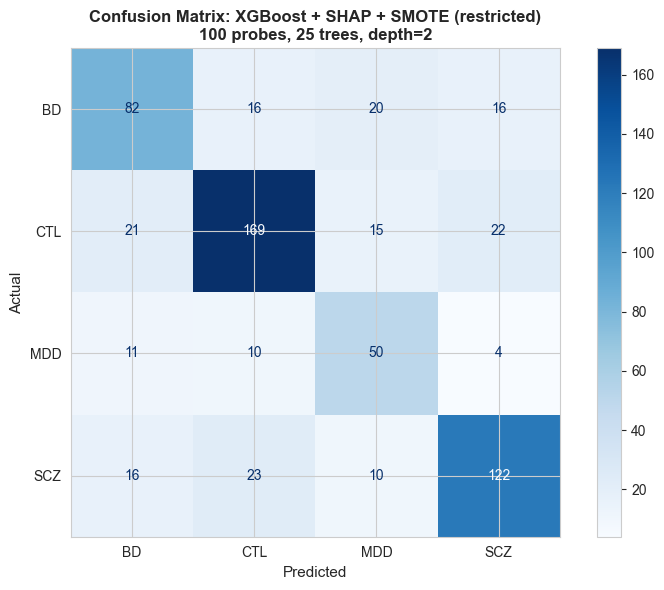

              precision    recall  f1-score   support

          BD       0.63      0.61      0.62       134
         CTL       0.78      0.74      0.76       227
         MDD       0.53      0.67      0.59        75
         SCZ       0.74      0.71      0.73       171

    accuracy                           0.70       607
   macro avg       0.67      0.68      0.67       607
weighted avg       0.70      0.70      0.70       607



In [61]:
# --- Confusion Matrix:  XGBoost 100 trees + SHAP 100 probes + SMOTE (restricted)
# (train score 0.946 )(test score 0.674 ) (No overfitting)  ---

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect predictions from all folds
y_true_all = []
y_pred_all = []

for train_idx, test_idx in cv.split(df[probes_5folds], y_encoded, groups):
    
    pipe = ImbPipeline(
        steps = [
            ('smote', SMOTE(random_state=42)),
            ('xgb', xgb.XGBClassifier(
                n_estimators=25,
                max_depth=2,
                learning_rate=0.3,
                eval_metric='mlogloss',
                random_state=42
            ))
        ]
    )
    
    pipe.fit(df[probes_5folds].iloc[train_idx], y_encoded[train_idx])
    y_pred = pipe.predict(df[probes_5folds].iloc[test_idx])
    
    y_true_all.extend(y_encoded[test_idx])
    y_pred_all.extend(y_pred)

# Create confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all)
class_names = le.classes_

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix: XGBoost + SHAP + SMOTE (restricted)\n100 probes, 25 trees, depth=2', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.savefig('../figures/03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
from sklearn.metrics import classification_report
print(classification_report(y_true_all, y_pred_all, target_names=class_names))

In [ ]:
## Confusion Matrix Analysis

### Per-Class Performance (XGBoost + SHAP + SMOTE, restricted, 100 probes)

| Class | Precision | Recall | F1 | Samples |
|---|---|---|---|---|
| CTL | 0.78 | 0.74 | 0.76 | 227 |
| SCZ | 0.74 | 0.71 | 0.73 | 171 |
| BD | 0.63 | 0.61 | 0.62 | 134 |
| MDD | 0.53 | 0.67 | 0.59 | 75 |

### Observations

**CTL (Control) is classified best (F1=0.76).** Healthy brains have distinct gene expression patterns. The SHAP analysis showed that NPTX2 and CAMK2A (synaptic markers) are the top features for identifying controls, suggesting healthy synaptic function is the clearest signal separating controls from patients.

**SCZ (Schizophrenia) is second best (F1=0.73).** SCZ has strong neuroinflammatory signatures (TREM2, S100A8) that distinguish it from other disorders. These genes are validated SCZ biomarkers in published literature.

**BD (Bipolar Disorder) is harder (F1=0.62).** BD shares molecular features with both SCZ and MDD. The PsychENCODE cross-disorder analysis (Gandal et al. 2018, Science) reported significant transcriptomic overlap between BD and SCZ, which explains the model's difficulty separating these two classes.

**MDD (Major Depression) is the hardest (F1=0.59).** Two factors contribute to this: (1) MDD has the fewest samples (75), giving the model less data to learn from, and (2) MDD gene expression changes in postmortem brain are subtle, with smaller effect sizes than SCZ (Gandal et al. 2018). The recall (0.67) is higher than precision (0.53), meaning the model catches most MDD cases but also misclassifies some BD or CTL samples as MDD.

### Clinical Relevance
The classification difficulty ranking (CTL > SCZ > BD > MDD) matches the clinical reality: psychiatric disorders exist on a spectrum with overlapping biology. The model captures this continuum rather than imposing artificial boundaries between disorders.

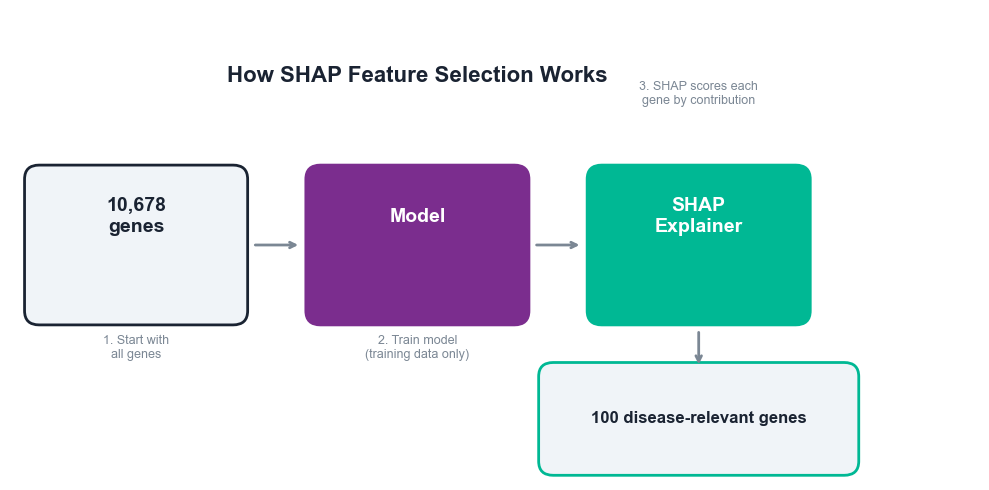

In [148]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis('off')

# Input box
ax.add_patch(mpatches.FancyBboxPatch((0.3, 1.8), 2.0, 1.4, boxstyle="round,pad=0.15", 
             facecolor='#F0F4F8', edgecolor='#1A2332', linewidth=2))
ax.text(1.3, 2.8, '10,678\ngenes', fontsize=14, ha='center', va='center', fontweight='bold', color='#1A2332')

# Arrow 1
ax.annotate('', xy=(3.0, 2.5), xytext=(2.5, 2.5),
            arrowprops=dict(arrowstyle='->', color='#7B8794', lw=2))

# Model box
ax.add_patch(mpatches.FancyBboxPatch((3.2, 1.8), 2.0, 1.4, boxstyle="round,pad=0.15",
             facecolor='#7B2D8E', edgecolor='#7B2D8E', linewidth=2))
ax.text(4.2, 2.8, 'Model', fontsize=14, ha='center', va='center', fontweight='bold', color='white')

# Arrow 2
ax.annotate('', xy=(5.9, 2.5), xytext=(5.4, 2.5),
            arrowprops=dict(arrowstyle='->', color='#7B8794', lw=2))

# SHAP box
ax.add_patch(mpatches.FancyBboxPatch((6.1, 1.8), 2.0, 1.4, boxstyle="round,pad=0.15",
             facecolor='#00B894', edgecolor='#00B894', linewidth=2))
ax.text(7.1, 2.8, 'SHAP\nExplainer', fontsize=14, ha='center', va='center', fontweight='bold', color='white')

# Arrow 3 down
ax.annotate('', xy=(7.1, 1.2), xytext=(7.1, 1.6),
            arrowprops=dict(arrowstyle='->', color='#7B8794', lw=2))

# Output box
ax.add_patch(mpatches.FancyBboxPatch((5.6, 0.2), 3.0, 0.9, boxstyle="round,pad=0.15",
             facecolor='#F0F4F8', edgecolor='#00B894', linewidth=2))
ax.text(7.1, 0.65, '100 disease-relevant genes', fontsize=12, ha='center', va='center', fontweight='bold', color='#1A2332')

# Top label
ax.text(4.2, 4.3, 'How SHAP Feature Selection Works', fontsize=16, ha='center', va='center', fontweight='bold', color='#1A2332')

# Step labels
ax.text(1.3, 1.3, '1. Start with\nall genes', fontsize=9, ha='center', color='#7B8794')
ax.text(4.2, 1.3, '2. Train model\n(training data only)', fontsize=9, ha='center', color='#7B8794')
ax.text(7.1, 4.0, '3. SHAP scores each\ngene by contribution', fontsize=9, ha='center', color='#7B8794')

plt.tight_layout()
plt.savefig('../figures/03_shap_concept.png', dpi=150, bbox_inches='tight')
plt.show()

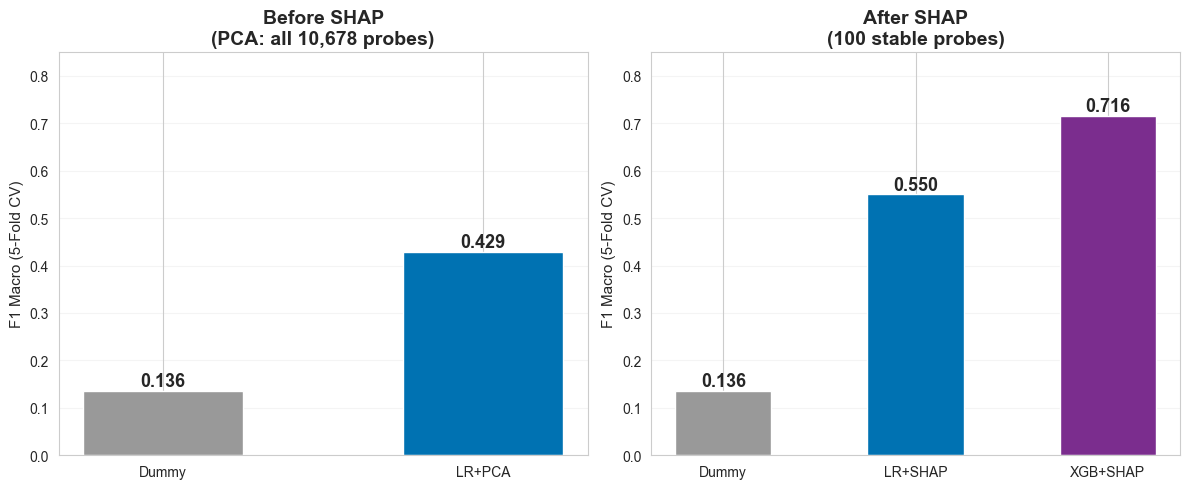

In [149]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Before (PCA)
models_before = ['Dummy', 'LR+PCA']
scores_before = [0.136, 0.429]
colors_before = ['#999999', '#0072B2']
axes[0].bar(models_before, scores_before, color=colors_before, width=0.5, edgecolor='white')
for i, v in enumerate(scores_before):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Before SHAP\n(PCA: all 10,678 probes)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('F1 Macro (5-Fold CV)', fontsize=11)
axes[0].set_ylim(0, 0.85)
axes[0].grid(True, alpha=0.2, axis='y')

# Right: After (SHAP)
models_after = ['Dummy', 'LR+SHAP', 'XGB+SHAP']
scores_after = [0.136, 0.550, 0.716]
colors_after = ['#999999', '#0072B2', '#7B2D8E']
axes[1].bar(models_after, scores_after, color=colors_after, width=0.5, edgecolor='white')
for i, v in enumerate(scores_after):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=13, fontweight='bold')
axes[1].set_title('After SHAP\n(100 stable probes)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1 Macro (5-Fold CV)', fontsize=11)
axes[1].set_ylim(0, 0.85)
axes[1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('../figures/03_shap_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
# --- Sanity Check 1: Data shapes ---
print(f"df shape: {df.shape}")
print(f"probe_cols: {len(probe_cols)}")
print(f"stable_probes: {len(stable_probes)}")
print(f"y_encoded shape: {y_encoded.shape}")
print(f"groups shape: {groups.shape}")
print(f"Class distribution: {np.bincount(y_encoded)}")
print(f"Class names: {le.classes_}")

# --- Sanity Check 2: CV splits are correct ---
for fold, (train_idx, test_idx) in enumerate(cv.split(df[stable_probes], y_encoded, groups)):
    train_patients = set(groups.iloc[train_idx])
    test_patients = set(groups.iloc[test_idx])
    overlap = train_patients & test_patients
    print(f"Fold {fold+1}: Train={len(train_idx)}, Test={len(test_idx)}, Patient overlap={len(overlap)}")

# --- Sanity Check 3: No data leakage in stable probes ---
print(f"\nStable probes are real probe IDs: {stable_probes[:3]}")
print(f"All stable probes in df: {all(p in df.columns for p in stable_probes)}")

# --- Sanity Check 4: Dummy classifier baseline ---
from sklearn.dummy import DummyClassifier
dummy_result = cross_validate(
    estimator=DummyClassifier(strategy='most_frequent'),
    X=df[stable_probes], y=y_encoded, groups=groups,
    scoring='f1_macro', cv=cv, return_train_score=True
)
print(f"\nDummy: Train={np.mean(dummy_result['train_score']):.3f}, Test={np.mean(dummy_result['test_score']):.3f}")

# --- Sanity Check 5: Verify best model score ---
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipe = ImbPipeline(
    steps = [
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb.XGBClassifier(
            n_estimators=25, max_depth=2, learning_rate=0.3,
            eval_metric='mlogloss', random_state=42
        ))
    ]
)

cv_check = cross_validate(
    estimator=pipe,
    X=df[stable_probes], y=y_encoded, groups=groups,
    scoring='f1_macro', cv=cv, return_train_score=True
)
print(f"SMOTE+XGB: Train={np.mean(cv_check['train_score']):.3f}, Test={np.mean(cv_check['test_score']):.3f}")

df shape: (607, 10686)
probe_cols: 10678
stable_probes: 100
y_encoded shape: (607,)
groups shape: (607,)
Class distribution: [134 227  75 171]
Class names: ['BD' 'CTL' 'MDD' 'SCZ']
Fold 1: Train=485, Test=122, Patient overlap=0
Fold 2: Train=485, Test=122, Patient overlap=0
Fold 3: Train=486, Test=121, Patient overlap=0
Fold 4: Train=486, Test=121, Patient overlap=0
Fold 5: Train=486, Test=121, Patient overlap=0

Stable probes are real probe IDs: ['201043_s_at', '201841_s_at', '202203_s_at']
All stable probes in df: True

Dummy: Train=0.136, Test=0.136
SMOTE+XGB: Train=0.946, Test=0.674


In [74]:
stable_probes = pd.read_csv('../data/stable_probes_100.csv')['0'].tolist()
print(f"Stable probes: {len(stable_probes)}")

Stable probes: 100


In [75]:
# Re-verify with 100 probes
pipe = ImbPipeline(
    steps = [
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb.XGBClassifier(
            n_estimators=25, max_depth=2, learning_rate=0.3,
            eval_metric='mlogloss', random_state=42
        ))
    ]
)

cv_check = cross_validate(
    estimator=pipe,
    X=df[stable_probes], y=y_encoded, groups=groups,
    scoring='f1_macro', cv=cv, return_train_score=True
)
print(f"SMOTE+XGB (100 probes): Train={np.mean(cv_check['train_score']):.3f}, Test={np.mean(cv_check['test_score']):.3f}")

SMOTE+XGB (100 probes): Train=0.946, Test=0.674


# Hierarchical Classification:

In [108]:
# --- Quick test: Binary CTL vs Psychiatric ---

y_binary = np.where(y_encoded == 1, 0, 1)  # CTL=0, all others=1
print(f"CTL: {np.sum(y_binary==0)}, Psychiatric: {np.sum(y_binary==1)}")

pipe = ImbPipeline(
    steps = [
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb.XGBClassifier(
            n_estimators=25, max_depth=2, learning_rate=0.3,
            eval_metric='logloss', random_state=42
        ))
    ]
)

cv_binary = cross_validate(
    estimator = pipe,
    X = df[stable_probes],
    y = y_binary,
    groups = groups,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"Binary (CTL vs Psychiatric) - Train: {np.mean(cv_binary['train_score']):.3f}, Test: {np.mean(cv_binary['test_score']):.3f}")

CTL: 227, Psychiatric: 380
Binary (CTL vs Psychiatric) - Train: 0.960, Test: 0.773


In [109]:
# --- Step 2: 3-class SCZ vs BD vs MDD (psychiatric only) ---

psych_mask = y_encoded != 1  # Remove CTL (class 1)
X_psych = df[stable_probes][psych_mask]
y_psych = y_encoded[psych_mask]
groups_psych = groups[psych_mask]

# Remap labels: BD=0, MDD=1, SCZ=2
le_psych = LabelEncoder()
y_psych_encoded = le_psych.fit_transform(df['diagnosis'][psych_mask])
print(f"Classes: {le_psych.classes_}, Counts: {np.bincount(y_psych_encoded)}")

pipe_psych = ImbPipeline(
    steps = [
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb.XGBClassifier(
            n_estimators=25, max_depth=2, learning_rate=0.3,
            eval_metric='mlogloss', random_state=42
        ))
    ]
)

cv_psych = cross_validate(
    estimator = pipe_psych,
    X = X_psych,
    y = y_psych_encoded,
    groups = groups_psych,
    scoring = 'f1_macro',
    cv = cv,
    return_train_score = True
)

print(f"3-class (SCZ vs BD vs MDD) - Train: {np.mean(cv_psych['train_score']):.3f}, Test: {np.mean(cv_psych['test_score']):.3f}")

Classes: ['BD' 'MDD' 'SCZ'], Counts: [134  75 171]
3-class (SCZ vs BD vs MDD) - Train: 0.985, Test: 0.715


In [110]:
# --- Step 1: CTL vs Psychiatric - Test LR and SVM ---

y_binary = np.where(y_encoded == 1, 0, 1)

# LR
for c_val in [0.01, 0.05, 0.1, 0.5, 1.0]:
    pipe = Pipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(
                class_weight='balanced', C=c_val, max_iter=5000
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[stable_probes],
        y = y_binary,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"Step 1 LR C={c_val} → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

print()

# SVM
for c_val in [1.0, 3.0, 5.0]:
    pipe = Pipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='rbf', C=c_val, gamma='scale', class_weight='balanced'))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[stable_probes],
        y = y_binary,
        groups = groups,
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"Step 1 SVM C={c_val} → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

Step 1 LR C=0.01 → Train: 0.775, Test: 0.688
Step 1 LR C=0.05 → Train: 0.816, Test: 0.708
Step 1 LR C=0.1 → Train: 0.825, Test: 0.699
Step 1 LR C=0.5 → Train: 0.834, Test: 0.708
Step 1 LR C=1.0 → Train: 0.834, Test: 0.707

Step 1 SVM C=1.0 → Train: 0.921, Test: 0.734
Step 1 SVM C=3.0 → Train: 0.984, Test: 0.727
Step 1 SVM C=5.0 → Train: 0.994, Test: 0.735


In [111]:
# --- Step 2: SCZ vs BD vs MDD - Test LR and SVM ---

psych_mask = y_encoded != 1
y_psych_encoded = le_psych.fit_transform(df['diagnosis'][psych_mask])

# LR
for c_val in [0.01, 0.05, 0.1, 0.5, 1.0]:
    pipe = Pipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(
                class_weight='balanced', C=c_val, max_iter=5000
            ))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[stable_probes][psych_mask],
        y = y_psych_encoded,
        groups = groups[psych_mask],
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"Step 2 LR C={c_val} → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

print()

# SVM
for c_val in [1.0, 3.0, 5.0]:
    pipe = Pipeline(
        steps = [
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='rbf', C=c_val, gamma='scale', class_weight='balanced'))
        ]
    )
    
    cv_result = cross_validate(
        estimator = pipe,
        X = df[stable_probes][psych_mask],
        y = y_psych_encoded,
        groups = groups[psych_mask],
        scoring = 'f1_macro',
        cv = cv,
        return_train_score = True
    )
    
    print(f"Step 2 SVM C={c_val} → Train: {np.mean(cv_result['train_score']):.3f}, Test: {np.mean(cv_result['test_score']):.3f}")

Step 2 LR C=0.01 → Train: 0.763, Test: 0.605
Step 2 LR C=0.05 → Train: 0.856, Test: 0.602
Step 2 LR C=0.1 → Train: 0.879, Test: 0.597
Step 2 LR C=0.5 → Train: 0.929, Test: 0.588
Step 2 LR C=1.0 → Train: 0.950, Test: 0.582

Step 2 SVM C=1.0 → Train: 0.871, Test: 0.649
Step 2 SVM C=3.0 → Train: 0.984, Test: 0.672
Step 2 SVM C=5.0 → Train: 0.998, Test: 0.673


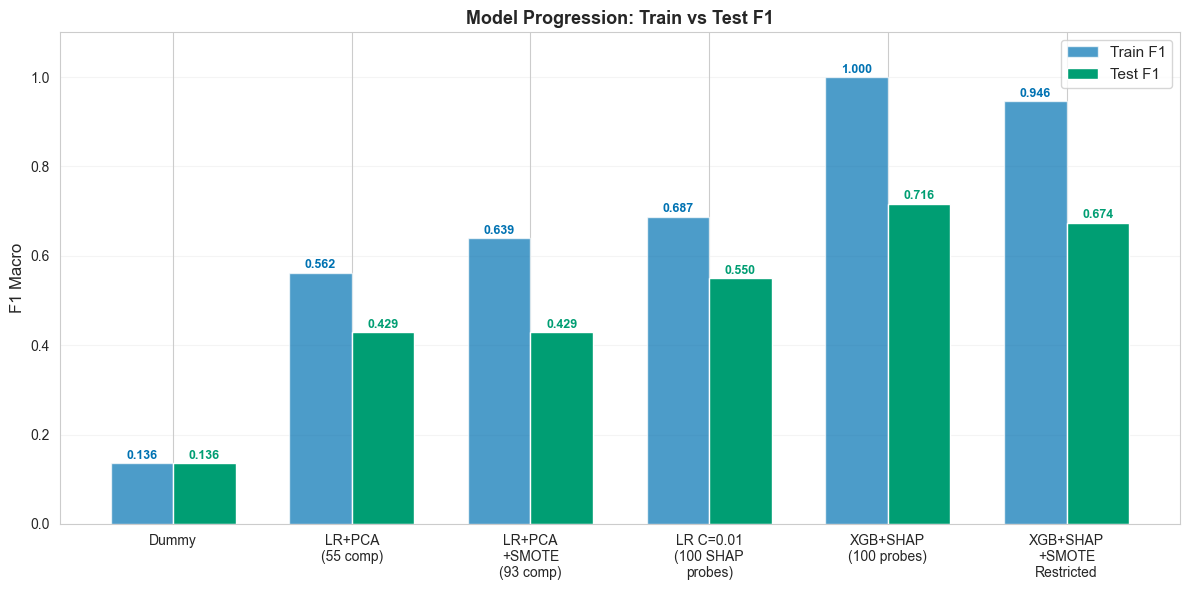

In [133]:
# --- Full Model Comparison ---
models = [
    'Dummy',
    'LR+PCA\n(55 comp)',
    'LR+PCA\n+SMOTE\n(93 comp)',
    'LR C=0.01\n(100 SHAP\nprobes)',
    'XGB+SHAP\n(100 probes)',
    'XGB+SHAP\n+SMOTE\nRestricted'
]

train_scores = [0.136, 0.562, 0.639, 0.687, 1.000, 0.946]
test_scores =  [0.136, 0.429, 0.429, 0.550, 0.716, 0.674]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models))
width = 0.35

bars_train = ax.bar(x - width/2, train_scores, width, label='Train F1', color='#0072B2', alpha=0.7)
bars_test = ax.bar(x + width/2, test_scores, width, label='Test F1', color='#009E73')

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#0072B2', fontweight='bold')
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#009E73', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('F1 Macro', fontsize=12)
ax.set_title('Model Progression: Train vs Test F1', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('../figures/03_full_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

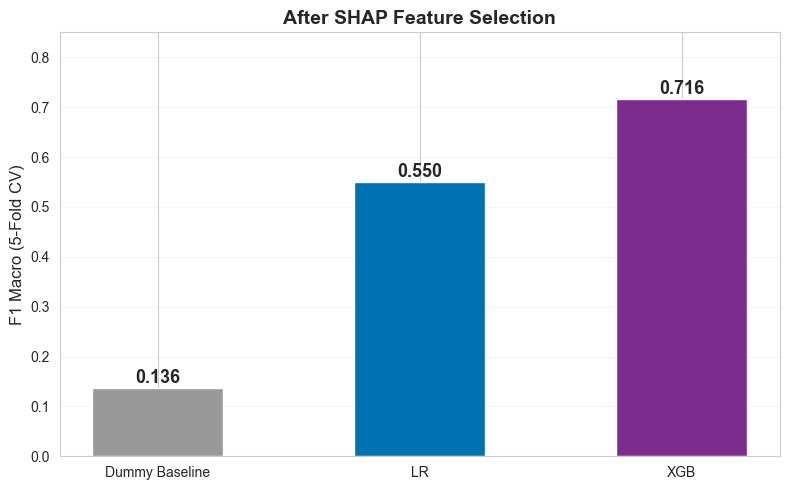

In [157]:
models = ['Dummy Baseline', 'LR', 'XGB']
test_scores = [0.136, 0.550, 0.716]
bar_colors = ['#999999', '#0072B2', '#7B2D8E']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, test_scores, color=bar_colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, test_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('F1 Macro (5-Fold CV)', fontsize=12)
ax.set_title('After SHAP Feature Selection', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('../figures/03_shap_models.png', dpi=150, bbox_inches='tight')
plt.show()

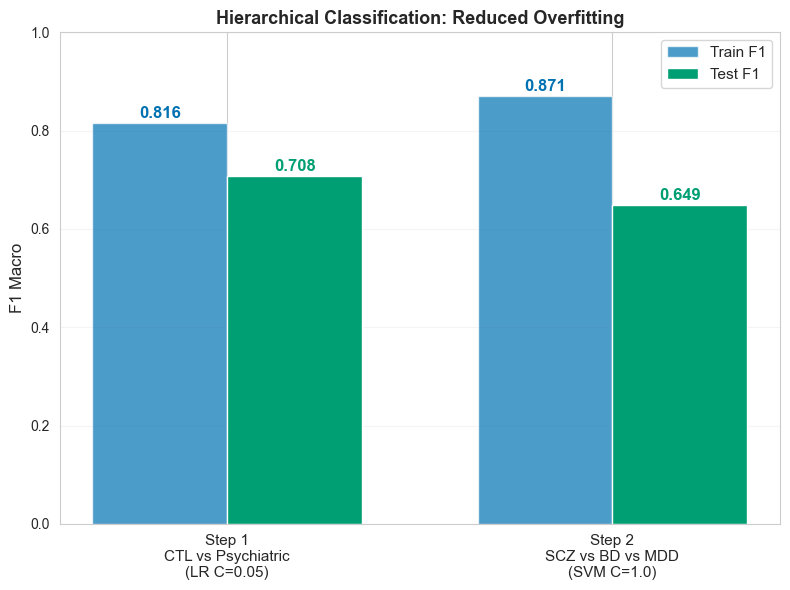

In [132]:
# --- Hierarchical Classification Results ---

steps = ['Step 1\nCTL vs Psychiatric\n(LR C=0.05)', 'Step 2\nSCZ vs BD vs MDD\n(SVM C=1.0)']
train_scores_h = [0.816, 0.871]
test_scores_h = [0.708, 0.649]

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(steps))
width = 0.35

bars_train = ax.bar(x - width/2, train_scores_h, width, label='Train F1', color='#0072B2', alpha=0.7)
bars_test = ax.bar(x + width/2, test_scores_h, width, label='Test F1', color='#009E73')

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=12, color='#0072B2', fontweight='bold')
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=12, color='#009E73', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(steps, fontsize=11)
ax.set_ylabel('F1 Macro', fontsize=12)
ax.set_title('Hierarchical Classification: Reduced Overfitting', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('../figures/03_hierarchical_results.png', dpi=150, bbox_inches='tight')
plt.show()

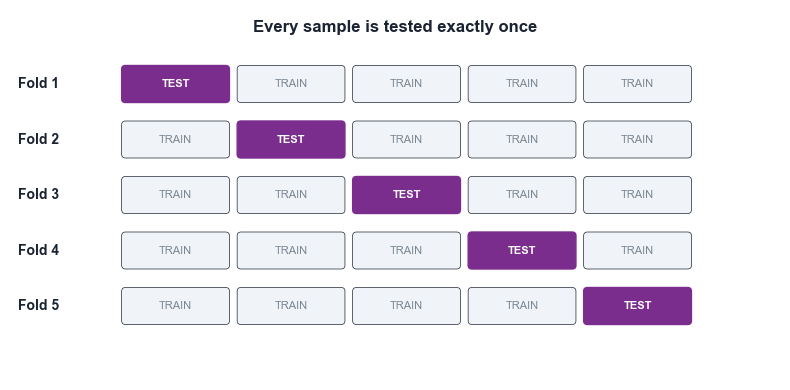

In [158]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis('off')

colors_fold = ['#7B2D8E', '#0072B2', '#009E73', '#999999', '#00B894']

for i in range(5):
    y = 4.0 - i * 0.75
    ax.text(0.1, y, f'Fold {i+1}', fontsize=10, va='center', fontweight='bold', color='#1A2332')
    
    for j in range(5):
        x = 1.5 + j * 1.5
        if j == i:
            ax.add_patch(mpatches.FancyBboxPatch((x, y-0.2), 1.3, 0.4, boxstyle="round,pad=0.05",
                         facecolor='#7B2D8E', edgecolor='#7B2D8E'))
            ax.text(x+0.65, y, 'TEST', fontsize=8, ha='center', va='center', color='white', fontweight='bold')
        else:
            ax.add_patch(mpatches.FancyBboxPatch((x, y-0.2), 1.3, 0.4, boxstyle="round,pad=0.05",
                         facecolor='#F0F4F8', edgecolor='#1A2332', linewidth=0.5))
            ax.text(x+0.65, y, 'TRAIN', fontsize=8, ha='center', va='center', color='#7B8794')

ax.text(5.0, 4.7, 'Every sample is tested exactly once', fontsize=12, ha='center', fontweight='bold', color='#1A2332')

plt.tight_layout()
plt.savefig('../figures/03_cv_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

In [159]:
import os

# Check project structure
for root, dirs, files in os.walk('..'):
    # Skip hidden folders and __pycache__
    dirs[:] = [d for d in dirs if not d.startswith('.') and d != '__pycache__' and d != 'node_modules' and d != '.venv']
    level = root.replace('..', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        if not file.startswith('.'):
            print(f'{subindent}{file}')

../
  LICENSE
  requirements.txt
  environment.yml
  Makefile
  __init__.py
  README.md
  images/
    untitled.md
    untitled.txt
    01_Data_Loading_Exploration
  models/
  docs/
  modeling/
    feature_engineering.py
    config.py
    predict.py
    train.py
  results/
  figures/
    03_shap_concept.png
    03_confusion_matrix.png
    03_shap_before_after.png
    03_initial_models.png
    03_class_distribution.png
    03_cv_diagram.png
    03_shap_top20_genes.png
    03_model_progression.png
    03_shap_per_class.png
    03_project_goal_diagram.png
    03_shap_models.png
    03_pca_by_diagnosis.png
    03_full_model_comparison.png
    03_hierarchical_results.png
    03_confusion_matrix_final.png
  data/
    stable_probes_783.csv
    stable_probes_758.csv
    stable_probes_100.csv
    processed/
      ml_ready.csv
      ml_ready_max_samples.csv
      patient_groups_max_samples.csv
    raw/
      GSE17612_series_matrix.txt
      GSE5389_series_matrix.txt
      GSE21138_series_matrix.t